In [258]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import re

In [259]:
# this file automatically pulls from the AlgoWiki
# spreadsheet and loads the relevant data

import requests
import bisect
import pandas as pd
from io import StringIO

ALGOWIKI_SHEET_ID = '1c6HTfHQfp7MIg1LFo6_wFOzKLIHA1rzVpDxXIPosRQ0'


# from https://stackoverflow.com/questions/37705553/how-to-export-a-csv-from-google-sheet-api
def make_url(sheet_name: str):
    return (f'https://docs.google.com/spreadsheets/d/' + 
    f'{ALGOWIKI_SHEET_ID}/gviz/tq?tqx=out:csv&sheet={sheet_name}')

def load_sheet(sheet_name: str) -> pd.DataFrame:
    url = make_url(sheet_name)
    response = requests.get(url)
    # i really hate how pandas can't just... read a csv from string wtf
    return pd.read_csv(StringIO(response.text))



In [260]:
# Load the approx algorithms dataset
columns = [
    'Family Name', 
    'Variation',
    'Algorithm Name', 
    'Year',
    'Looked at?',
    'Use For Inapprox?',
    'Parallel?',
    'Time Complexity Class',
    'Approximation Factor (if approximate algorithm)',
    'Approximation Factor Class (Mult)', 
    'Approximation Factor Class (Add)',
    'Approximation Type (additive/multiplicative)',	
    'Parametrized Approximation?',
    'Type of PTAS (if PTAS)',
    'Quantum?'
]
approximation_algorithms = load_sheet('Approx Algos')[columns]

# Clean and prepare the data
# drop Looked at? == 0.001 or 0
approximation_algorithms = approximation_algorithms[approximation_algorithms['Looked at?'] != '0.001']
approximation_algorithms = approximation_algorithms[approximation_algorithms['Looked at?'] != '0']
# drop Relevant? == 0
include_even_if_not_use_for_inapprox = {
    'Approximate Symmetric TSP (with gamma-parameterized triangle ineq)',
    'Subset Sum (Approximate)',
    'The k-Set Packing Problem, Unweighted (Approximate)',
}
use_for_inapprox = (approximation_algorithms['Use For Inapprox?'] != 0) & (approximation_algorithms['Use For Inapprox?'] != '0')
included_variation = approximation_algorithms['Variation'].isin(include_even_if_not_use_for_inapprox)
approximation_algorithms = approximation_algorithms[use_for_inapprox | included_variation]

# filter out parallel algorithms
approximation_algorithms = approximation_algorithms[approximation_algorithms['Parallel?'] != '1']

approximation_algorithms = approximation_algorithms[approximation_algorithms['Quantum?'] != '1']
approximation_algorithms = approximation_algorithms[approximation_algorithms['Quantum?'] != 1]

# separate entries with >1 variants into multiple entries
for idx, row in approximation_algorithms.iterrows():
    variations = row['Variation']
    if ';' not in variations:
        continue
    approximation_algorithms = approximation_algorithms.drop(index=idx)
    variation_sep = [s.strip() for s in variations.split(';')]
    for variation in variation_sep:
        series = row.copy()
        series['Variation'] = variation
        frame = series.to_frame().T
        approximation_algorithms = pd.concat([approximation_algorithms, frame], ignore_index=True)
    


approximation_algorithms['Year'] = pd.to_numeric(approximation_algorithms['Year'].astype(str).str.extract(r'(\d{4})')[0], errors='coerce')
approximation_algorithms.dropna(subset=['Year'], inplace=True)
# approximation_algorithms['Year'] = approximation_algorithms['Year'].astype(int)

# drop empty family names
approximation_algorithms = approximation_algorithms[approximation_algorithms['Family Name'].notnull()]

for col in ['Time Complexity Class', 'Approximation Factor Class (Mult)', 'Approximation Factor Class (Add)']:
    # Extract numeric (float) from string
    approximation_algorithms[col] = approximation_algorithms[col].astype(str).str.extract(r'(\d+\.?\d*)')[0].astype(float)
    approximation_algorithms[col] = approximation_algorithms[col].replace(0, 99999)
    

# approximation_algorithms.sort_values(by=['Family Name', 'Year', 'Variation'], inplace=True)

approximation_algorithms

,Family Name,Variation,Algorithm Name,Year,Looked at?,Use For Inapprox?,Parallel?,Time Complexity Class,Approximation Factor (if approximate algorithm),Approximation Factor Class (Mult),Approximation Factor Class (Add),Approximation Type (additive/multiplicative),Parametrized Approximation?,Type of PTAS (if PTAS),Quantum?
0,Graph Coloring,Chromatic Number Approximation,Johnson,1974.0,1.0,1,0.0,5.00,O(n/log n),8.99,99999.0,multiplicative,no,NaN,0.0
1,Graph Coloring,Chromatic Number Approximation,Wigderson,1983.0,1.0,1,0.0,6.01,O((n((log log n)/(log n))^2),8.98,99999.0,multiplicative,no,NaN,0.0
2,Graph Coloring,Chromatic Number Approximation,"Berger, Rompel",1990.0,1.0,1,0.0,7.00,eps*n((log log n)/(log n))^3,8.98,99999.0,multiplicative,yes,NaN,0.0
3,Graph Coloring,Chromatic Number Approximation,"Boppana, Halldorsson",1992.0,1.0,1,0.0,7.00,O(n/(log n)^2),8.98,99999.0,multiplicative,no,NaN,0.0
4,Graph Coloring,Chromatic Number Approximation,Halldorsson,1993.0,1.0,1,0.0,7.00,O(n(log log n)^2/(log n)^3),8.98,99999.0,multiplicative,no,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124,Boolean CNF-Satisfiability,Max-SAT,"Kohli, Krishnamurti",1989.0,1.0,1,0.0,7.00,"2/3, expected",2.50,99999.0,multiplicative,no,NaN,0.0
125,Clique Problems,Max-Size Clique (Approximate),"Boppana, Halldorsson",1992.0,1.0,1,0.0,7.00,O(n/(log n)^2),8.98,99999.0,multiplicative,no,NaN,0.0
126,Clique Problems,Max-Size Clique (Approximate),Feige,2004.0,1.0,1,0.0,7.00,O(n(log log n)^2/(log n)^3),8.98,99999.0,multiplicative,no,NaN,0.0
127,The Set-Covering Problem,Unweighted Set-Covering,Integer linear program Vazirani,2001.0,1.0,1,0.0,7.00,\log U,6.00,99999.0,multiplicative,no,NaN,0.0


In [261]:
# Load the approx lower bounds dataset

bound_type_title = ('Type of Bound \n'
    + '(trivial - obvious, full - has been proved and published, \n'
    + 'none - no bound, -- is an extra resource and not a bound )')

columns = [
    'Problem Family', 
    'Problem Variation',
    'Relevant?',  
     bound_type_title,
    'Run Time Lower Bound',
    'Exact Inapprox. Ratio',
    'Parameter',
    'Rounded Inapprox Ratio',
    'Approximation Factor Class (Mult)',
    'Year',
    'Conditional conjecture',
]
approximation_lower_bounds = load_sheet('inapprox')[columns]

# Clean and prepare the data

# drop Relevant? == 0
include_even_if_not_relevant = {
    'Subset Sum (Approximate)',
}
is_relevant = (approximation_lower_bounds['Relevant?'] != 0) & (approximation_lower_bounds['Relevant?'] != '0')
included_variation = approximation_lower_bounds['Problem Variation'].isin(include_even_if_not_relevant)
approximation_lower_bounds = approximation_lower_bounds[is_relevant | included_variation]



#approximation_lower_bounds['Year'] = pd.to_numeric(approximation_algorithms['Year'].str.extract(r'(\d{4})')[0], errors='coerce')
#approximation_lower_bounds.dropna(subset=['Year'], inplace=True)

# drop empty family names
approximation_lower_bounds = approximation_lower_bounds[approximation_lower_bounds['Problem Family'].notnull()]
approximation_lower_bounds['Problem Family'] = approximation_lower_bounds['Problem Family'].replace({
    'The Subset Sum Problem': 'The Subset-Sum Problem',
})

# drop trivial upper bounds from the lower bounds data
approximation_lower_bounds = approximation_lower_bounds[approximation_lower_bounds[bound_type_title] != "trivial"]

approximation_lower_bounds.sort_values(by=['Problem Family', 'Year', 'Problem Variation'], inplace=True)

approximation_lower_bounds


,Problem Family,Problem Variation,Relevant?,"Type of Bound \n(trivial - obvious, full - has been proved and published, \nnone - no bound, -- is an extra resource and not a bound )",Run Time Lower Bound,Exact Inapprox. Ratio,Parameter,Rounded Inapprox Ratio,Approximation Factor Class (Mult),Year,Conditional conjecture
36,Boolean 2-Satisfiability,Max-2SAT,1.0,NaN,polynomial,PTAS,NaN,NaN,2.000,1991.0,no problem in MaxSNP has a PTAS
39,Boolean 2-Satisfiability,Max-2SAT,1.0,NaN,polynomial,PTAS,NaN,NaN,2.000,1991.0,no problem in MaxSNP has a PTAS
37,Boolean 2-Satisfiability,Max-2SAT,1.0,NaN,polynomial,$1.013$,NaN,$1.013$,2.013,1995.0,P not equal NP
40,Boolean 2-Satisfiability,Max-2SAT,1.0,NaN,polynomial,$\frac{22}{21}-\epsilon$,any epsilon>0,$1.047619$,2.047,2001.0,P not equal NP
41,Boolean 2-Satisfiability,Max-2SAT,1.0,NaN,polynomial,$\approx\frac{1}{0.943943}-\epsilon$,any epsilon>0,$1.059386$,2.059,2007.0,"Unique Games Conjecture, P not equal NP"
...,...,...,...,...,...,...,...,...,...,...,...
97,The Vertex Cover Problem,"The Vertex Cover Problem, General (Approximate)",1.0,NaN,polynomial,$2-\epsilon$,any epsilon>0,$2$,2.990,2007.0,"Unique Games Conjecture, P not equal NP"
98,The Vertex Cover Problem,"The Vertex Cover Problem, Sparse (Approximate)",1.0,NaN,polynomial,$2 - (2+o(1))\frac{\log\log d}{\log d}$,d - maximum degree,$2$,2.990,2009.0,"Unique Games Conjecture, P not equal NP"
96,The Vertex Cover Problem,"The Vertex Cover Problem, General (Approximate)",1.0,NaN,polynomial,$\tfrac{3}{2}$,NaN,$\frac{3}{2}$,2.500,2015.0,?
95,The Vertex Cover Problem,"The Vertex Cover Problem, General (Approximate)",1.0,NaN,polynomial,$\sqrt2-\epsilon$,any epsilon>0,$1.414214$,2.414,2017.0,P not equal NP


In [262]:
ratios = approximation_algorithms[['Family Name', 'Approximation Factor (if approximate algorithm)', 'Approximation Factor Class (Mult)', 'Approximation Factor Class (Add)']]

# i gave up on using pandas to filter this 
ratios_list = [list(row) for _, row in ratios.iterrows()]

ptases = [row for row in ratios_list if isinstance(row[1], str) and 'eps' in row[1]]
ptases

[['Graph Coloring', 'eps*n((log log n)/(log n))^3', 8.98, 99999.0],
 ['The Subset-Sum Problem', '1 - eps', 2.0, 99999.0],
 ['The Subset-Sum Problem', '1 - eps', 2.0, 99999.0],
 ['The Subset-Sum Problem', '1 - eps', 2.0, 99999.0],
 ['The Subset-Sum Problem', '1 - eps', 2.0, 99999.0],
 ['The Subset-Sum Problem', '1 - eps', 2.0, 99999.0],
 ['The Subset-Sum Problem', '1 - eps', 2.0, 99999.0],
 ['The Subset-Sum Problem', '1 - eps', 2.0, 99999.0],
 ['The Vertex Cover Problem', '2/(1+eps)', 2.99, 99999.0],
 ['The Set-Covering Problem', '(1+eps)(1 + ln d)', 6.0, 99999.0],
 ['The Set-Covering Problem', '(1+eps)(1 + ln U)', 6.0, 99999.0],
 ['The Set-Covering Problem', 'f/(1-eps)', 8.9, 99999.0],
 ['Wiener Index', '(1+eps)', 2.0, 99999.0],
 ['Wiener Index', '(1+eps)', 2.0, 99999.0],
 ['Independent Set', '(Delta + 3.25)/5 + eps', 9.0, 99999.0],
 ['Independent Set', '(Delta + 3.25)/5 + eps', 9.0, 99999.0],
 ['Independent Set', '(Delta + 7/3)/4 + eps', 9.0, 99999.0],
 ['The Set Packing Problem', 'k/

In [263]:

def simplify_conjecture(conjecture):

    if 'DTIME' in conjecture: 
        return 'ETH'
        # return 'NP not a subset of DTIME(2^polylog n)'
    elif 'ZPTIME' in conjecture or 'ZTIME' in conjecture:
        return 'NP not a subset of ZPTIME(2^polylog n)'
    elif 'BPTIME' in conjecture:
        return 'NP not a subset of BPTIME(2^polylog n)'
    elif 'RP' in conjecture or 'ZPP' in conjecture or 'coR' in conjecture: # dumb typo edge case
        return 'NP not a subset of BPP'
    elif 'NP not solvable in' in conjecture:
        return 'ETH' # equivalent to quasi
    elif 'NP does not have a quasi-polynomial' in conjecture:
        return 'ETH' # i think, todo check eth implies this?
    elif conjecture in ['?', 
                        'no problem in MaxSNP has a PTAS', 
                        'Max 2SAT doesn\'t have randomized PTAS', 
                        '$\\tilde{P}\\neq N\\tilde{P}$']:
        return 'Miscellaneous/Unknown'
    else:
        return conjecture

def categorize_conjecture(conjecture):
    simple = simplify_conjecture(conjecture)
    print(simple)
    if 'ETH' in simple:
        return 'ETH'
    elif 'BPTIME' in simple or 'ZPTIME' in simple or 'BPP' in simple:
        return 'Randomized'
    elif 'W[1]' in simple or 'FPT' in simple:
        return 'W[1]-hard'
    elif 'NEXP' in simple:
        return 'Exponential Complexity'
    elif 'Games' in simple:
        return 'Games'
    else:
        return simple

conjecture_categories = ['ETH', 'Miscellaneous/Unknown', 'P not equal NP', 'Games', 'Exponential Complexity', 'Randomized', 'W[1]-hard']


Miscellaneous/Unknown
Miscellaneous/Unknown
P not equal NP
P not equal NP
Unique Games Conjecture, P not equal NP
Unique Games Conjecture, P not equal NP
NP not a subset of BPP
EXP not a subset of NEXP
P not equal NP
Miscellaneous/Unknown
P not equal NP
P not equal NP
P not equal NP
P not equal NP
NP not a subset of BPP
P not equal NP
P not equal NP
P not equal NP
NP not a subset of BPP
NEXP not a subset of BPEXP
NP not a subset of BPP
NP not a subset of BPP
NP not a subset of BPP
P not equal NP
P not equal NP
NP not a subset of BPP
ETH
ETH
P not equal NP
NP not a subset of BPP
NP not a subset of BPP
NP not a subset of ZPTIME(2^polylog n)
P not equal NP
NP not a subset of BPP
NP not a subset of ZPTIME(2^polylog n)
NP not a subset of BPTIME(2^polylog n)
P not equal NP
ETH
P not equal NP
P not equal NP
ETH
W[1] != FPT
ETH
W[1] != FPT
ETH
SETH
Gap ETH
P not equal NP
NP not a subset of BPP
NEXP not a subset of BPEXP
P not equal NP
NP not a subset of BPP
NP not a subset of BPP
NP not a subs

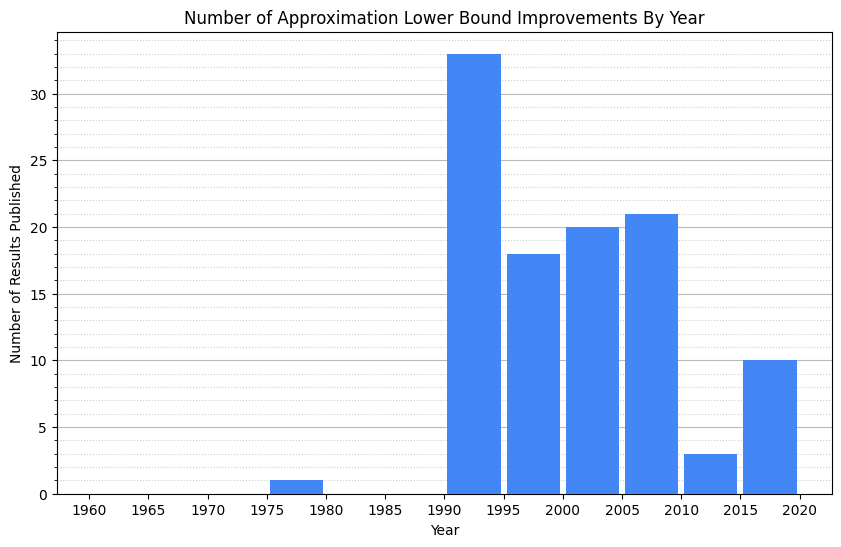

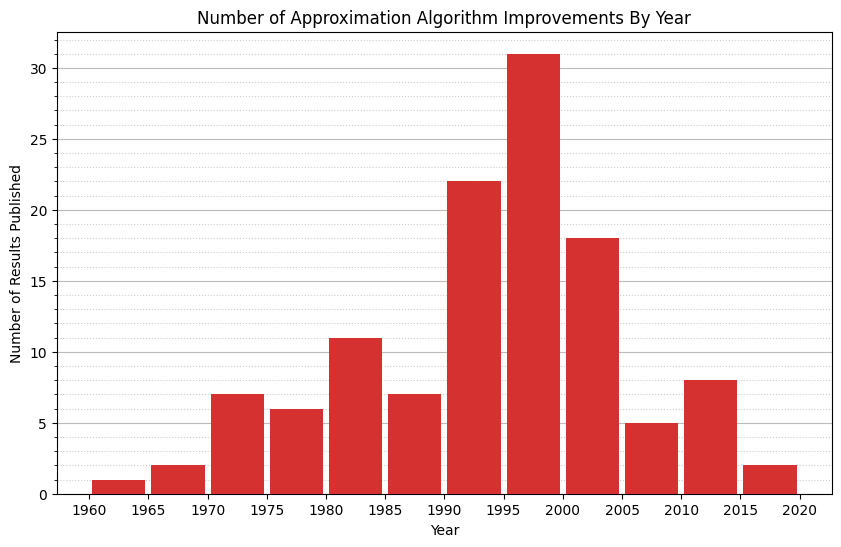

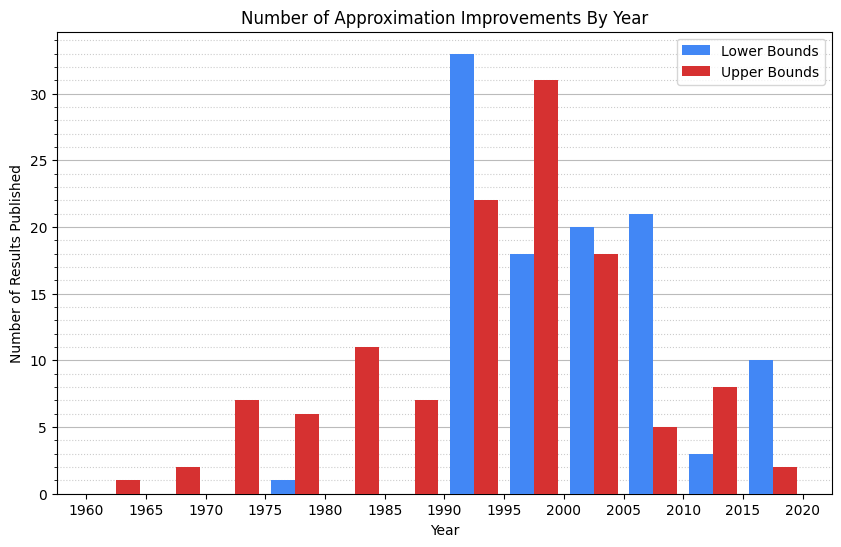

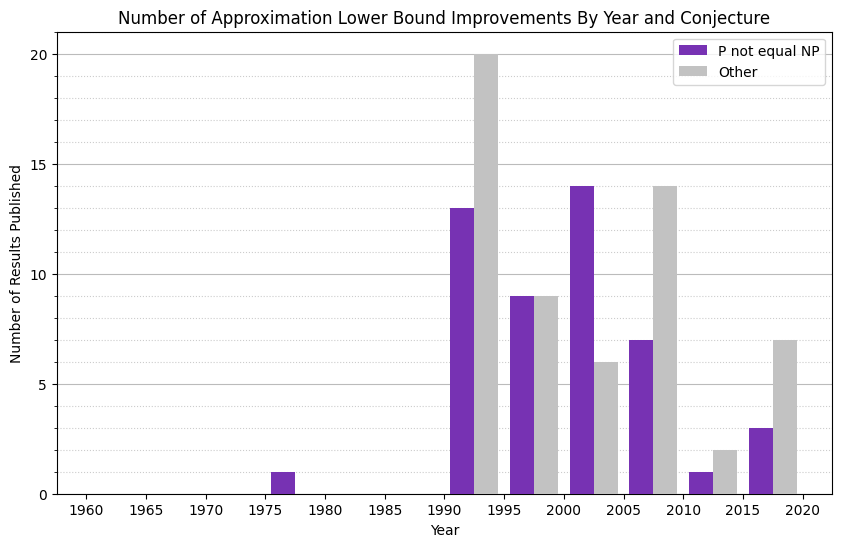

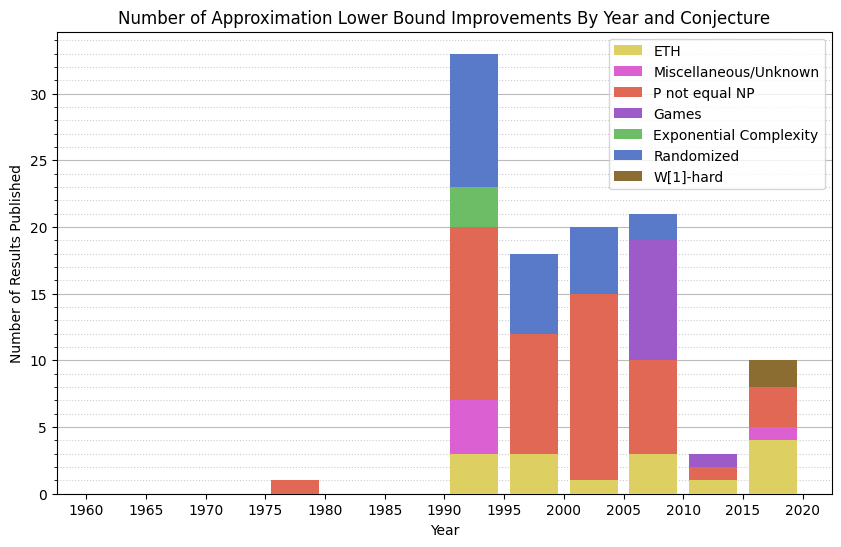

In [264]:
# plot by year
start_year = 1960
end_year = 2025
bin_size = 5
bins = list(range(start_year, end_year, bin_size))


def format_plot(fig, ax):
  ax.set_xticks(np.arange(start_year, end_year, bin_size))
  fig.set_facecolor('white')
  ax.grid(axis='y', zorder=-500, which='major', color='#bbbbbb')
  ax.grid(axis='y', zorder=0, which='minor', color='#cccccc', linestyle=':', linewidth=0.8)
  ax.minorticks_on()
  ax.xaxis.minorticks_off()
  ax.yaxis.set_minor_locator(ticker.MultipleLocator(1))
  ax.yaxis.set_major_locator(ticker.MultipleLocator(5))

# lower bounds

def plot_hist_years(dataset, title, color):
  fig, ax = plt.subplots()
  fig.set_size_inches(10, 6)

  data = list(dataset["Year"])

  ax.hist(data, bins=bins, rwidth=0.9, zorder=100, color=color)
  format_plot(fig, ax)

  ax.set_title(title)
  ax.set_xlabel('Year')
  ax.set_ylabel('Number of Results Published')

  return data



labels = ['Lower Bounds', 'Upper Bounds']
colors = ['#4287f5', '#d63131']
lower_years = plot_hist_years(approximation_lower_bounds, 'Number of Approximation Lower Bound Improvements By Year', colors[0])
upper_years = plot_hist_years(approximation_algorithms, 'Number of Approximation Algorithm Improvements By Year', colors[1])

# plot both together
fig, ax = plt.subplots()
fig.set_size_inches(10, 6)
ax.hist([lower_years, upper_years], bins=list(range(start_year, end_year, bin_size)), color=colors, label=labels, zorder=100)
format_plot(fig, ax)
ax.set_title('Number of Approximation Improvements By Year')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Results Published')
ax.legend(labels)

# separate P neq NP


# by conjecture
pnp_results = approximation_lower_bounds[approximation_lower_bounds['Conditional conjecture'] == 'P not equal NP']['Year']
not_pnp_results = approximation_lower_bounds[approximation_lower_bounds['Conditional conjecture'] != 'P not equal NP']['Year']

fig, ax = plt.subplots()
labels = ['P not equal NP', 'Other']
colors = ['#7732b3', '#c2c2c2']
fig.set_size_inches(10, 6)
ax.hist([pnp_results, not_pnp_results], bins=list(range(start_year, end_year, bin_size)), color=colors, label=labels, zorder=100)
format_plot(fig, ax)
ax.set_title('Number of Approximation Lower Bound Improvements By Year and Conjecture')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Results Published')
ax.legend(labels)

data = {k: [] for k in conjecture_categories}

for _, row in approximation_lower_bounds.iterrows():
  data[categorize_conjecture(row['Conditional conjecture'])].append(row['Year'])

data = [v for k, v in data.items()]
labels = conjecture_categories

fig, ax = plt.subplots()
colors = ['#decf62', '#db60d1', '#e06855', '#9d5bc9', '#6cbd66', '#597ac9', '#8c6d31']
fig.set_size_inches(10, 6)
ax.hist(data, bins=list(range(start_year, end_year, bin_size)), color=colors, label=labels, zorder=100, stacked=True, rwidth=0.8, align='mid')
format_plot(fig, ax)
ax.set_title('Number of Approximation Lower Bound Improvements By Year and Conjecture')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Results Published')
ax.legend(labels)

plt.show()


['P not equal NP', 'Unique Games Conjecture, P not equal NP', 'coRP not equal NP', 'ETH', 'NP not a subset of BPP', 'NP not a subset of ZPTIME(2^((log n)^(O(1))))', 'NP not equal ZPP', 'no problem in MaxSNP has a PTAS', 'NEXP not a subset of BPEXP', 'NP not a subset of coRP', '$coRP \\neq NP$', 'NP not in $DTIME(2^{\\mathrm{polylog}\\, n})$', 'W[1] != FPT', 'Other']
[48, 9, 5, 4, 3, 3, 3, 2, 2, 2, 2, 2, 2, 19]


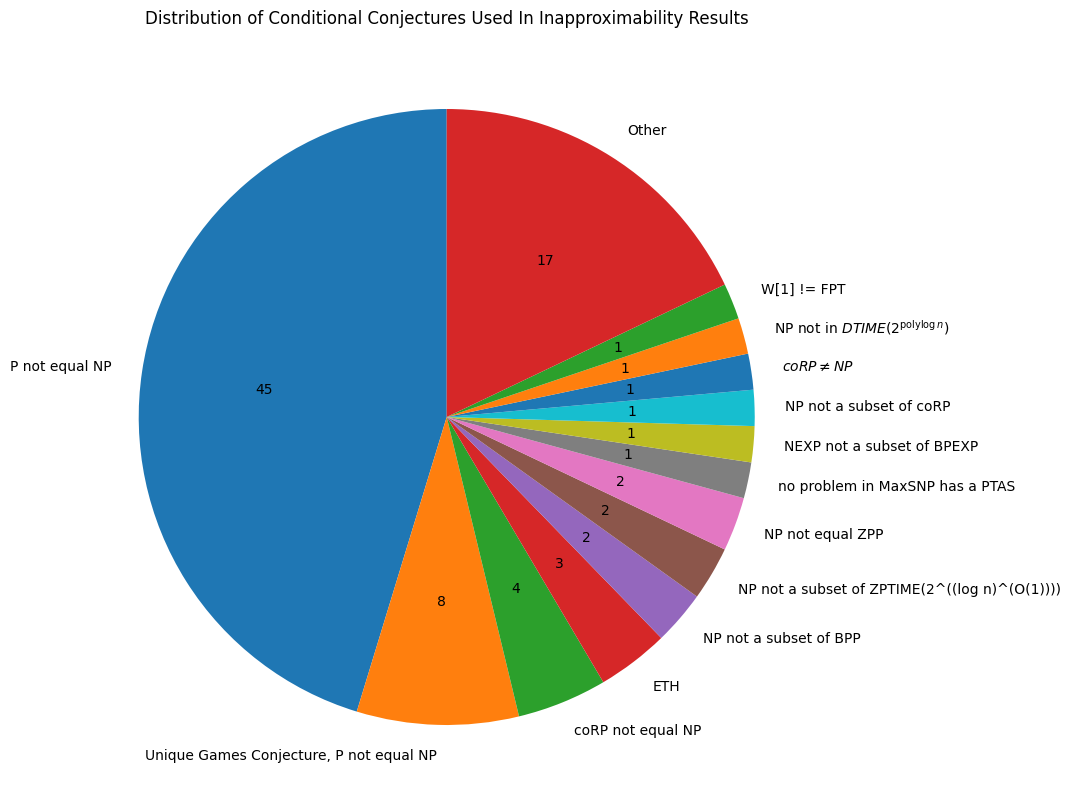

In [265]:
conjectures = {}

for _, row in approximation_lower_bounds.iterrows():
    conj = row['Conditional conjecture']
    conjectures[conj] = conjectures.get(conj, 0) + 1

# lump all the conjectures with 1 lower bound to "other"
other_threshold = 1
conjectures_to_plot = {'Other': 0}

for conj, num in conjectures.items():
    if num <= other_threshold:
        conjectures_to_plot['Other'] += num
    else:
        conjectures_to_plot[conj] = num
    
conjectures
pairs = [(conj, num) for conj, num in conjectures_to_plot.items()]
pairs.sort(key=lambda x: x[1]+(-10000 if x[0]=='Other' else 0), reverse=True)
def format_conjecture_label(conjecture):
    if conjecture == 'NP not in $DTIME(2^{poly \\log n})$ (or $\\tilde{P}\\neq N\\tilde{P}$)':
        return r'NP not in $DTIME(2^{\mathrm{polylog}\, n})$'
    if conjecture == '$coR\\tilde{P}\\neq N\\tilde{P}$':
        return r'$coRP \neq NP$'
    return conjecture

labels = [format_conjecture_label(x[0]) for x in pairs]
sizes = [x[1] for x in pairs]

print(labels)
print(sizes)

fig, ax = plt.subplots()
ax.set_title('Distribution of Conditional Conjectures Used In Inapproximability Results')
fig.set_size_inches(10, 10)
fig.set_facecolor('white')
ax.pie(sizes, labels=labels, autopct='%d', startangle=90)
plt.show()


# todo: by problem
# "strongest" lower bound?
# lump the xTIME() together, potentially

# todo: lump techniques used in the results

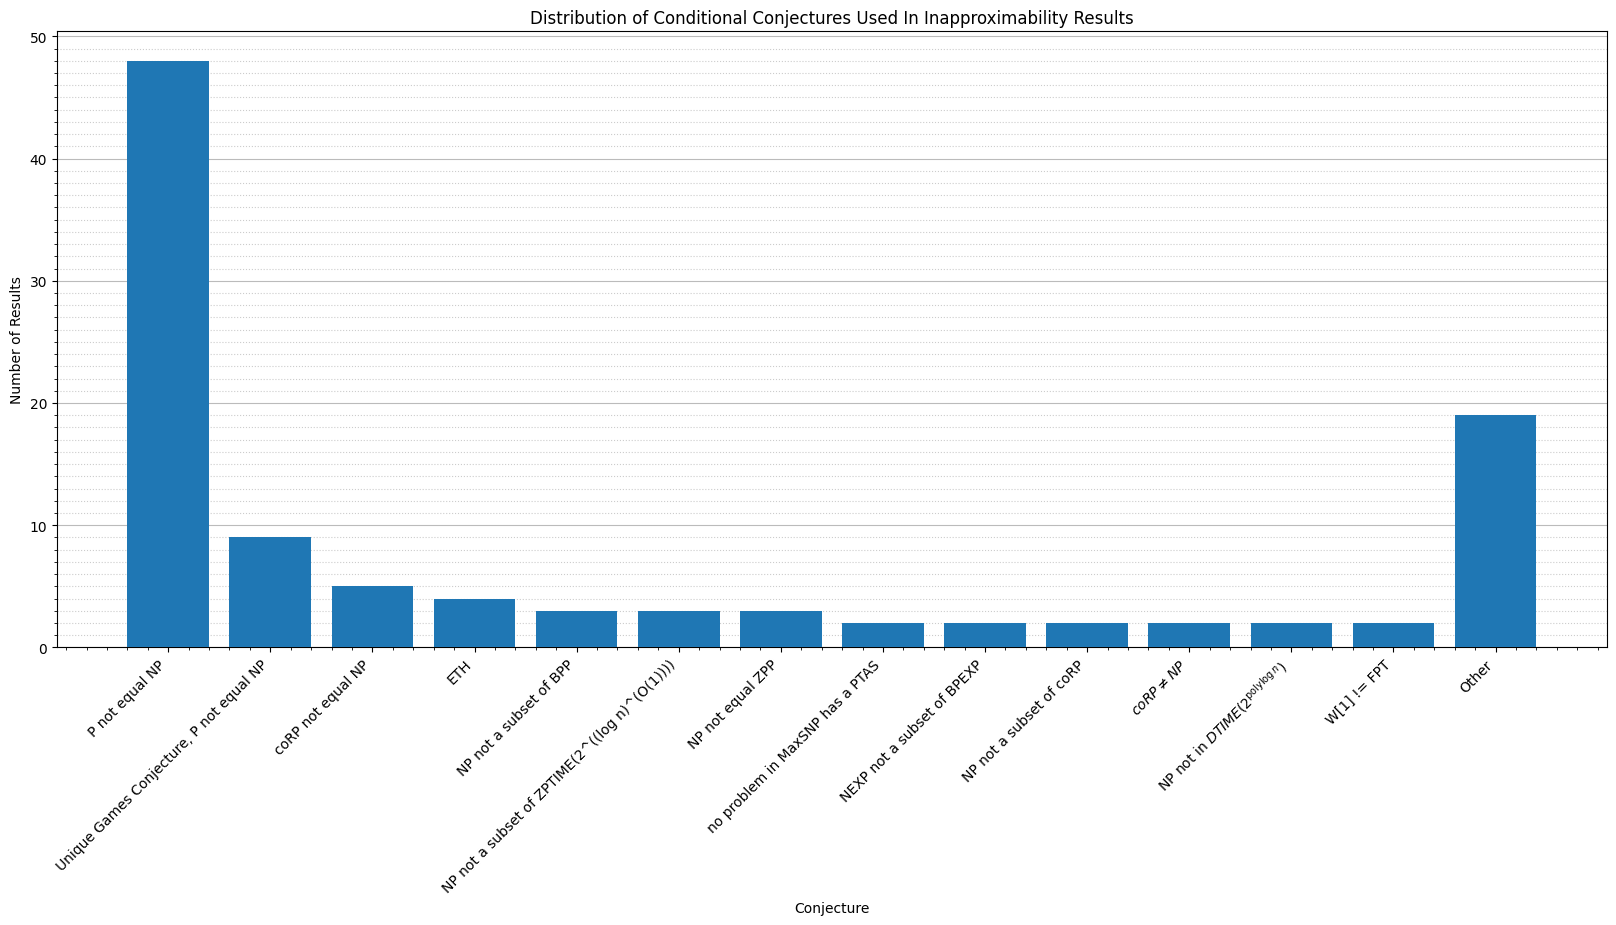

In [266]:
fig, ax = plt.subplots()
ax.set_title('Distribution of Conditional Conjectures Used In Inapproximability Results')
ax.set_xlabel('Conjecture')
ax.set_ylabel('Number of Results')
fig.set_size_inches(20, 8)
fig.set_facecolor('white')
ax.bar(labels, sizes, zorder=100)
ax.grid(axis='y', which='major', color='#bbbbbb')
ax.grid(axis='y', which='minor', color='#cccccc', linestyle=':', linewidth=0.8)
ax.minorticks_on()
ax.yaxis.set_minor_locator(ticker.MultipleLocator(1))
plt.xticks(rotation=45, ha='right')
plt.show()
conjectures_family_sets: dict[str, set[str]] = {}


{'no problem in MaxSNP has a PTAS': 1,
 'P not equal NP': 15,
 'Unique Games Conjecture, P not equal NP': 7,
 'NP not a subset of BPP': 3,
 'EXP not a subset of NEXP': 1,
 '$\\tilde{P}\\neq N\\tilde{P}$': 1,
 'RP not equal NP': 1,
 'NEXP not a subset of BPEXP': 2,
 'NP not a subset of coRP': 2,
 '$coR\\tilde{P}\\neq N\\tilde{P}$': 2,
 'coRP not equal NP': 2,
 'NP not a subset of DTIME(n^(O(log log n)))': 1,
 'NP not a subset of DTIME(2^((log n)^(O(1))))': 1,
 'NP not equal coR': 1,
 'NP not a subset of ZPTIME(2^((log n)^(O(1))))': 2,
 'NP not equal ZPP': 2,
 'NP not a subset of ZPTIME(2^(O(log n(log log n)^3/2))': 1,
 'NP not a subset of BPTIME(2^((log n)^(O(1))))': 1,
 'NP not in $DTIME(2^{poly \\log n})$ (or $\\tilde{P}\\neq N\\tilde{P}$)': 2,
 'NP not in DTIME(n^O(log log n))': 1,
 'W[1] != FPT': 1,
 'ETH': 3,
 'SETH': 1,
 'Gap ETH': 1,
 "Max 2SAT doesn't have randomized PTAS": 1,
 'NP does not have a quasi-polynomial deterministic time simulation': 1,
 'NP not in DTIME(n^(log log n

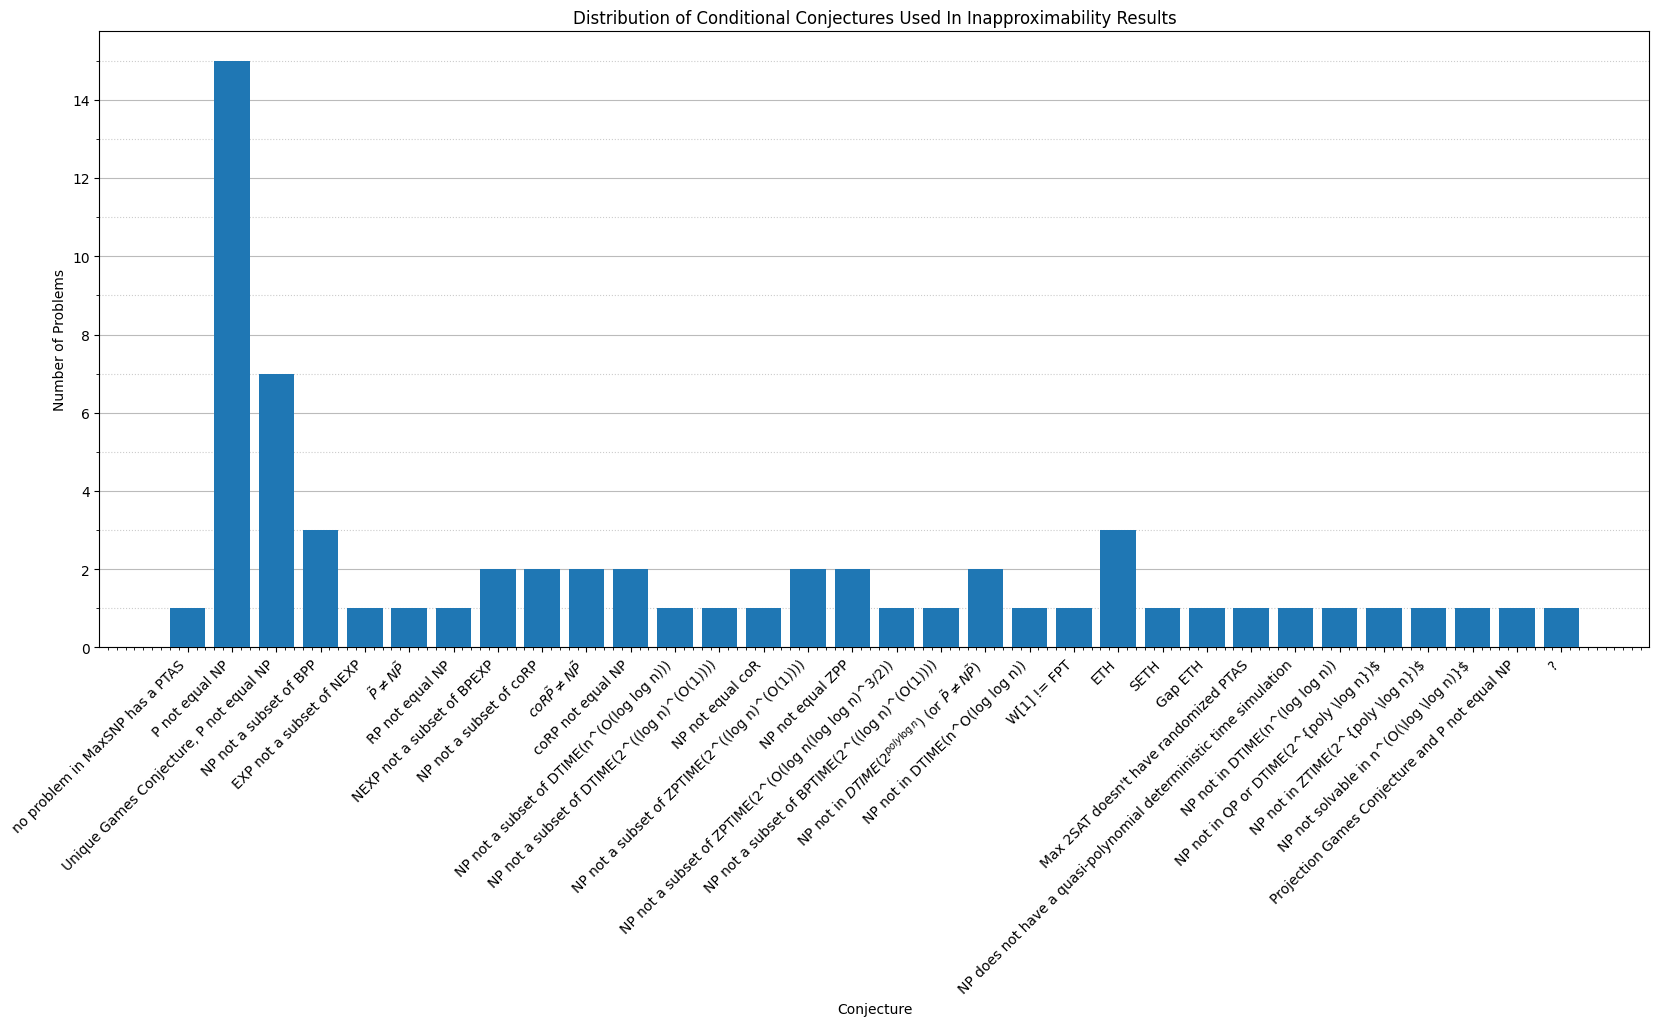

In [267]:

# group results in the same problem family together as one
for _, row in approximation_lower_bounds.iterrows():
    conj = row['Conditional conjecture']
    conjectures_family_sets.setdefault(conj, set()).add(row['Problem Family'])

conjectures_family_counts = {conj: len(families) for conj, families in conjectures_family_sets.items()}

import pprint
pprint.pp(conjectures_family_counts)

pairs = [(k, v) for k, v in conjectures_family_counts.items()]
labels = [pair[0] for pair in pairs]
sizes = [pair[1] for pair in pairs]

fig, ax = plt.subplots()
ax.set_title('Distribution of Conditional Conjectures Used In Inapproximability Results')
ax.set_xlabel('Conjecture')
ax.set_ylabel('Number of Problems')
fig.set_size_inches(20, 8)
fig.set_facecolor('white')
ax.bar(labels, sizes, zorder=100)
ax.grid(axis='y', which='major', color='#bbbbbb')
ax.grid(axis='y', which='minor', color='#cccccc', linestyle=':', linewidth=0.8)
ax.minorticks_on()
ax.yaxis.set_minor_locator(ticker.MultipleLocator(1))
plt.xticks(rotation=45, ha='right')
plt.show()


no problem in MaxSNP has a PTAS
Miscellaneous/Unknown

no problem in MaxSNP has a PTAS
Miscellaneous/Unknown

P not equal NP
P not equal NP

P not equal NP
P not equal NP

Unique Games Conjecture, P not equal NP
Unique Games Conjecture, P not equal NP

Unique Games Conjecture, P not equal NP
Unique Games Conjecture, P not equal NP

NP not a subset of BPP
NP not a subset of BPP

EXP not a subset of NEXP
EXP not a subset of NEXP

P not equal NP
P not equal NP

$\tilde{P}\neq N\tilde{P}$
Miscellaneous/Unknown

P not equal NP
P not equal NP

P not equal NP
P not equal NP

P not equal NP
P not equal NP

P not equal NP
P not equal NP

RP not equal NP
NP not a subset of BPP

P not equal NP
P not equal NP

P not equal NP
P not equal NP

P not equal NP
P not equal NP

NP not a subset of BPP
NP not a subset of BPP

NEXP not a subset of BPEXP
NEXP not a subset of BPEXP

NP not a subset of coRP
NP not a subset of BPP

$coR\tilde{P}\neq N\tilde{P}$
NP not a subset of BPP

coRP not equal NP
NP not a

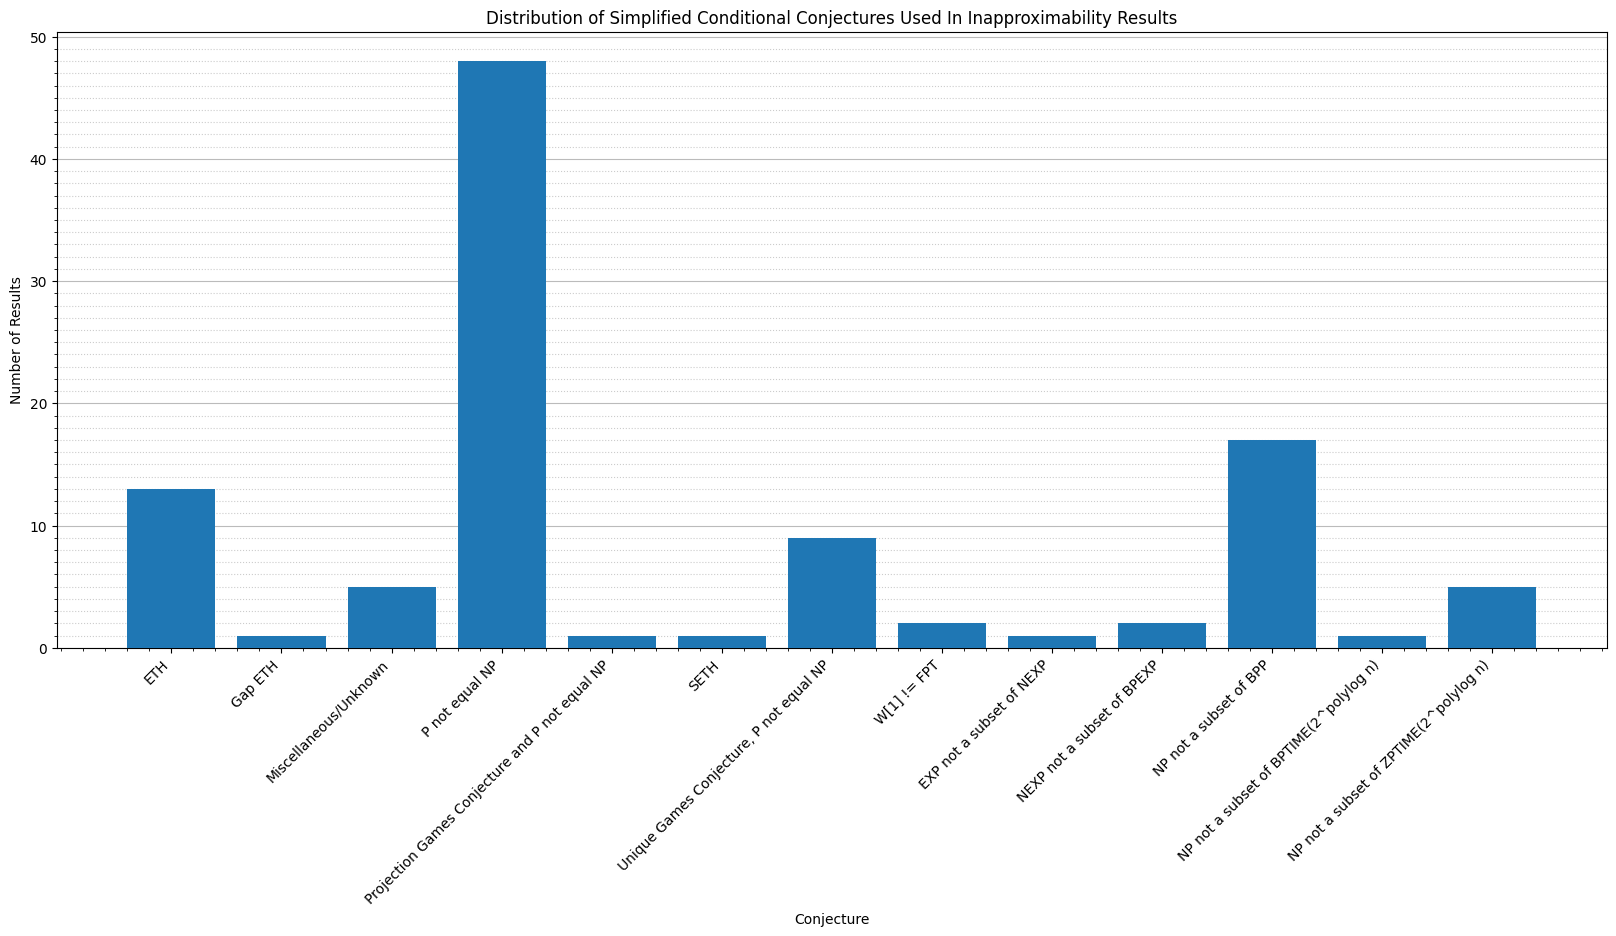

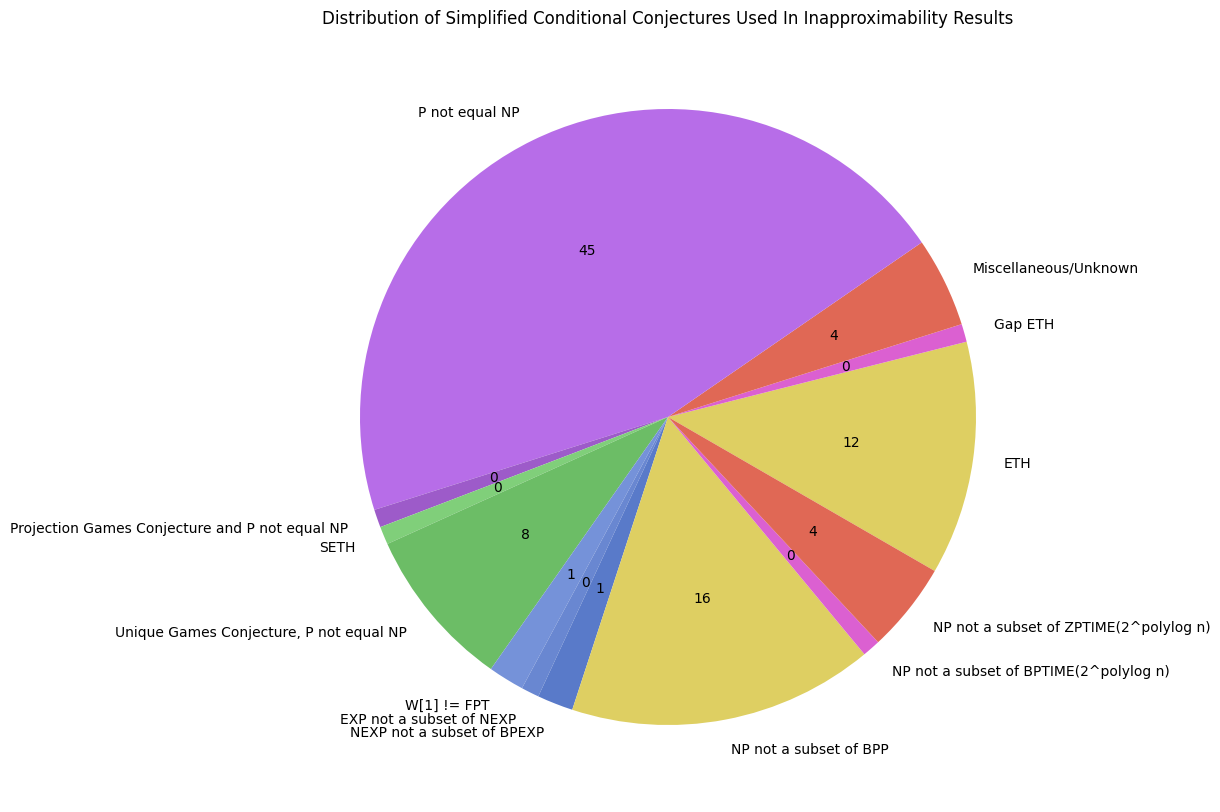

In [268]:


conjectures_family_simplify_counts = {}

# group results in the same problem family together as one
for _, row in approximation_lower_bounds.iterrows():
    original_conj = row['Conditional conjecture']
    conj = simplify_conjecture(original_conj)
    conjectures_family_simplify_counts[conj] = conjectures_family_simplify_counts.get(conj, 0) + 1
    print(original_conj, conj, sep='\n')
    print()

pprint.pp(conjectures_family_simplify_counts)

pairs = [(k, v) for k, v in conjectures_family_simplify_counts.items()]
pairs.sort(key=lambda p: p[0])
pairs.sort(key=lambda p: 'not a subset of' in p[0])
labels = [pair[0] for pair in pairs]
sizes = [pair[1] for pair in pairs]
colors = ['#decf62', '#db60d1', '#e06855', '#b76de8', '#9d5bc9', '#80cf7a', '#6cbd66', '#7592d9', '#6987d1', '#597ac9']
print(sizes)
print(len(colors), len(sizes))

fig, ax = plt.subplots()
ax.set_title('Distribution of Simplified Conditional Conjectures Used In Inapproximability Results')
ax.set_xlabel('Conjecture')
ax.set_ylabel('Number of Results')
fig.set_size_inches(20, 8)
fig.set_facecolor('white')
ax.bar(labels, sizes, zorder=100)
ax.grid(axis='y', which='major', color='#bbbbbb')
ax.grid(axis='y', which='minor', color='#cccccc', linestyle=':', linewidth=0.8)
ax.minorticks_on()
ax.yaxis.set_minor_locator(ticker.MultipleLocator(1))
plt.xticks(rotation=45, ha='right')


fig, ax = plt.subplots()
ax.set_title('Distribution of Simplified Conditional Conjectures Used In Inapproximability Results')
fig.set_size_inches(10, 10)
fig.set_facecolor('white')
ax.pie(sizes, labels=labels, autopct='%d', startangle=330, colors=colors)
plt.show()

# TODO: add lines for readability

Miscellaneous/Unknown
no problem in MaxSNP has a PTAS
Miscellaneous/Unknown

Miscellaneous/Unknown
no problem in MaxSNP has a PTAS
Miscellaneous/Unknown

P not equal NP
P not equal NP
P not equal NP

P not equal NP
P not equal NP
P not equal NP

Unique Games Conjecture, P not equal NP
Unique Games Conjecture, P not equal NP
Games

Unique Games Conjecture, P not equal NP
Unique Games Conjecture, P not equal NP
Games

NP not a subset of BPP
NP not a subset of BPP
Randomized

EXP not a subset of NEXP
EXP not a subset of NEXP
Exponential Complexity

P not equal NP
P not equal NP
P not equal NP

Miscellaneous/Unknown
$\tilde{P}\neq N\tilde{P}$
Miscellaneous/Unknown

P not equal NP
P not equal NP
P not equal NP

P not equal NP
P not equal NP
P not equal NP

P not equal NP
P not equal NP
P not equal NP

P not equal NP
P not equal NP
P not equal NP

NP not a subset of BPP
RP not equal NP
Randomized

P not equal NP
P not equal NP
P not equal NP

P not equal NP
P not equal NP
P not equal NP

P n

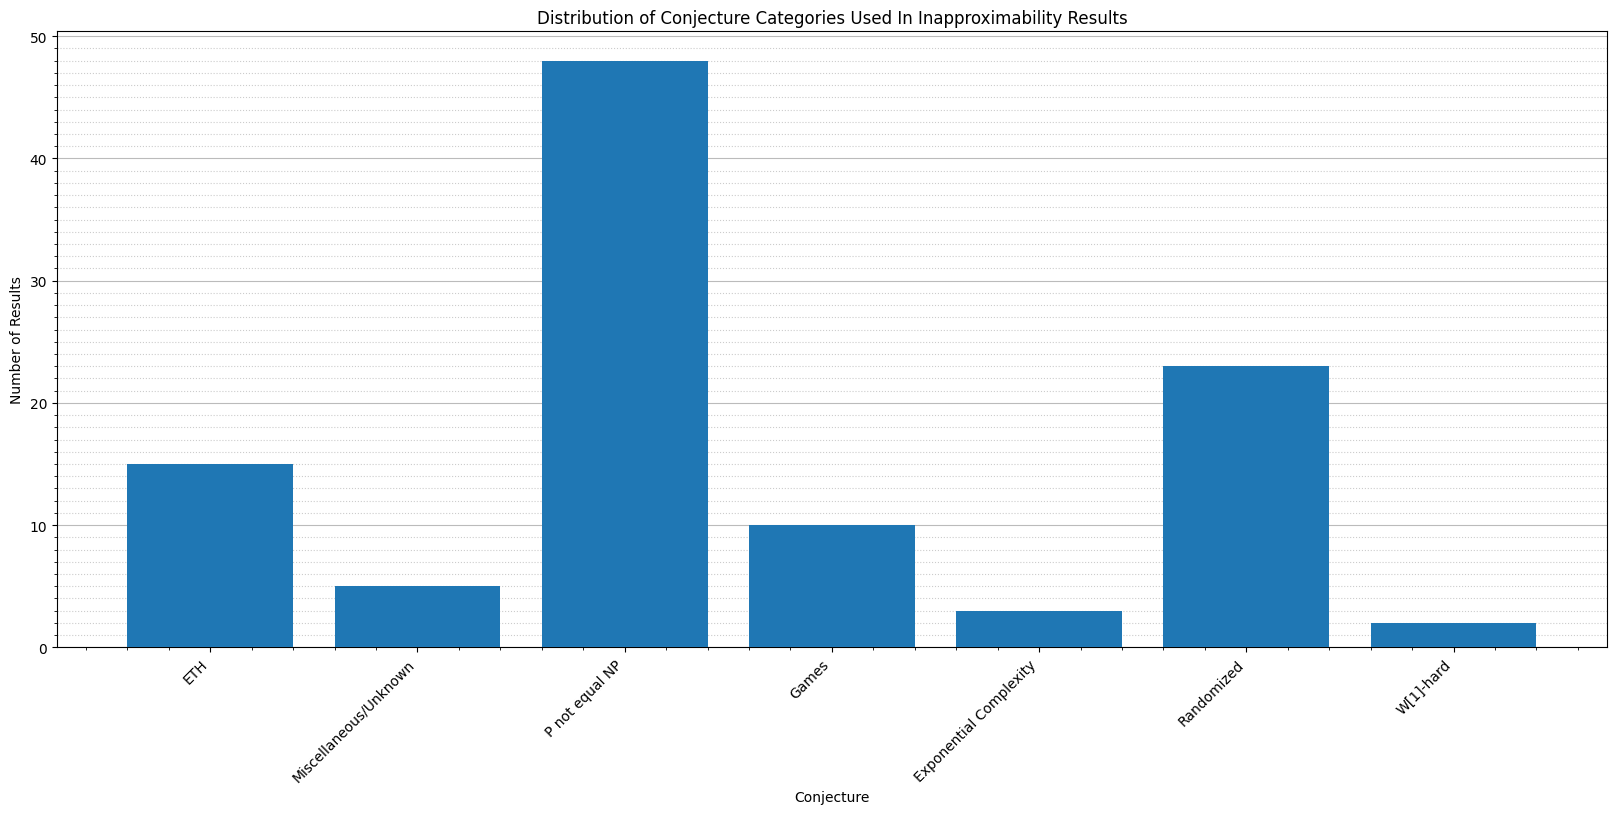

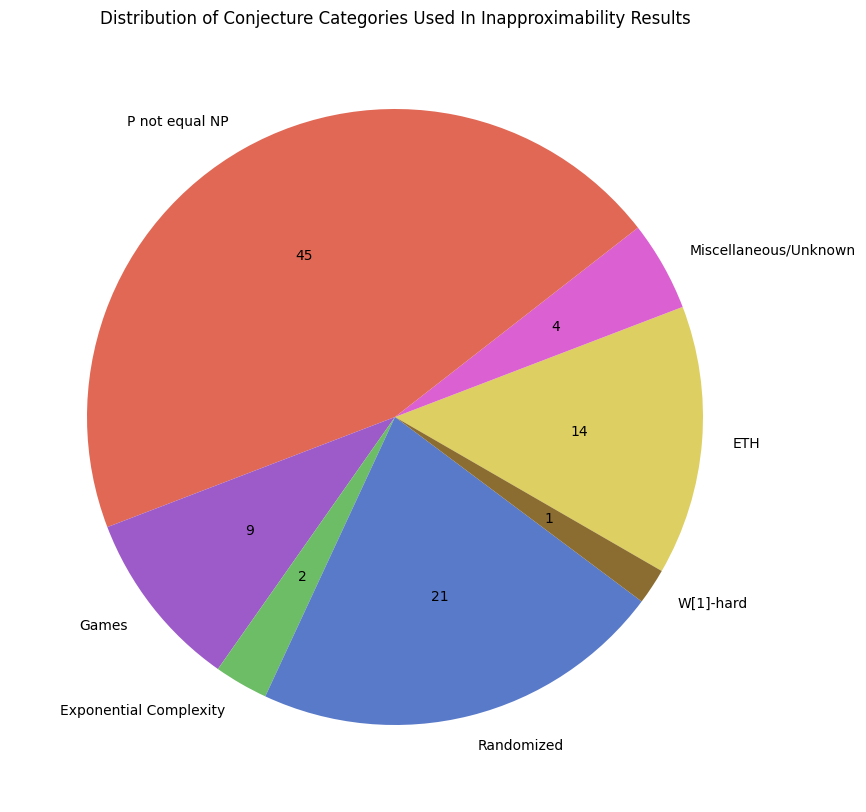

In [269]:
conjectures_category_counts = {}

# group results in the same problem family together as one
for _, row in approximation_lower_bounds.iterrows():
    original_conj = row['Conditional conjecture']
    conj = categorize_conjecture(original_conj)
    conjectures_category_counts[conj] = conjectures_category_counts.get(conj, 0) + 1
    print(original_conj, conj, sep='\n')
    print()

labels = conjecture_categories
sizes = [conjectures_category_counts[category] for category in labels]
colors = ['#decf62', '#db60d1', '#e06855', '#9d5bc9', '#6cbd66', '#597ac9', '#8c6d31']
print(sizes)
print(len(colors), len(sizes))

fig, ax = plt.subplots()
ax.set_title('Distribution of Conjecture Categories Used In Inapproximability Results')
ax.set_xlabel('Conjecture')
ax.set_ylabel('Number of Results')
fig.set_size_inches(20, 8)
fig.set_facecolor('white')
ax.bar(labels, sizes, zorder=100)
ax.grid(axis='y', which='major', color='#bbbbbb')
ax.grid(axis='y', which='minor', color='#cccccc', linestyle=':', linewidth=0.8)
ax.minorticks_on()
ax.yaxis.set_minor_locator(ticker.MultipleLocator(1))
plt.xticks(rotation=45, ha='right')


fig, ax = plt.subplots()
ax.set_title('Distribution of Conjecture Categories Used In Inapproximability Results')
fig.set_size_inches(10, 10)
fig.set_facecolor('white')
ax.pie(sizes, labels=labels, autopct='%d', startangle=330, colors=colors)
plt.show()



# todo: by problem

# categories:
# exp groups
# UGC/PGC

# P neq NP
# quasi-poly (BPTIME, ZPTIME, etc.)
# ETH alone???

# NP not in BPP (or related)
# (also lump in DTIME)



In [270]:
mappings = {
 'Max-2SAT': 'Max-2SAT',
 'Max Weighted 2SAT': 'Max Weighted 2SAT',
 'Max-3SAT': 'Max-3SAT',
 'Max-SAT': 'Max-SAT',
 'Max-Size Clique (Approximate)': 'Max-Size\nClique',
 'Chromatic Number Approximation': 'Chromatic\nNumber',
 'Independent Set (Approximate)': 'Independent Set',
 'Longest Path, Directed (Approximate)': 'Longest Path,\nDirected',
 'Longest Path, Undirected (Approximate)': 'Longest Path,\nGeneral', 
 'Longest Path, General (Approximate)': 'Longest Path,\nGeneral',
 'Maximum Cut, Approximate': 'Maximum Cut',
 'Unweighted Set-Covering': 'Unweighted\nSet-Convering',
 'Unweighted Set-Covering; Weighted Set-Covering': 'Unweighted\nSet-Convering',
 'Approximate Metric TSP': 'Metric TSP',
 'Approximate Symmetric TSP': 'Symmetric TSP',
 'The Vertex Cover Problem, Sparse (Approximate)': 'Vertex Cover,\nSparse',
 'The Vertex Cover Problem, General (Approximate)': 'Vertex Cover,\nGeneral',
 'The Vertex Cover Problem, Unweighted (Approximate)': 'Vertex Cover,\nUnweighted',
 'The Vertex Cover Problem, Unweighted, Dense (Approximate)': 'Vertex Cover\n, Unweighted, Dense',
 'The Vertex Cover Problem, Weighted (Approximate)': 'Vertex Cover\n, Weighted',
 'Minimum Wiener Connector problem': 'Minimum Wiener\nConnector',   
}

problems: tuple[str, str] = []

for _, row in approximation_algorithms.iterrows():
    problems.append((row['Family Name'], row['Variation']))
    
for _, row in approximation_lower_bounds.iterrows():
    problems.append((row['Problem Family'], row['Problem Variation']))
    
set(problems)



{('Boolean 2-Satisfiability', 'Max Weighted 2SAT'),
 ('Boolean 2-Satisfiability', 'Max-2SAT'),
 ('Boolean 3-Satisfiability', 'Max-3SAT'),
 ('Boolean CNF-Satisfiability', 'Max-SAT'),
 ('Clique Problems', 'Max-Size Clique (Approximate)'),
 ('Dominating Set', 'Every vertex has degree at most 4'),
 ('Dominating Set', 'Every vertex has degree at most d, d big enough'),
 ('Dominating Set', 'Minimum size dominating set'),
 ('Graph Coloring', 'Chromatic Number Approximation'),
 ('Independent Set', 'Independent Set (Approximate)'),
 ('Longest Path Problem', 'Longest Path, Directed (Approximate)'),
 ('Longest Path Problem', 'Longest Path, General (Approximate)'),
 ('Longest Path Problem', 'Longest Path, Undirected (Approximate)'),
 ('Maximum Bisection', 'Maximum Bisection, Weighted, Approximate'),
 ('Maximum Cut', 'Maximum Cut, Approximate'),
 ('The Set Packing Problem',
  'The k-Set Packing Problem, Unweighted (Approximate)'),
 ('The Set Splitting Problem', 'Max 3-Set Splitting'),
 ('The Set Sp

In [271]:
# None indicates no shorthand, use original name
short_names = {k: (v if v else k) for k, v in { 
 'Max-2SAT': None,
 'Max Weighted 2SAT': 'Max-2SAT', # temporary hack since we don't have lower bounds yet?
 'Max-3SAT': None,
 'Max-SAT': None,
 'Max-Size Clique (Approximate)': 'Max-Size\nClique',
 'Chromatic Number Approximation': 'Chromatic\nNumber',
 'Independent Set (Approximate)': 'Independent Set',
 'Longest Path, Directed (Approximate)': 'Longest Path',
 'Longest Path, General (Approximate)': 'Longest Path',
 'Maximum Cut, Approximate': 'Maximum Cut',
 'Unweighted Set-Covering': 'Unweighted\nSet-Convering',
 'Approximate Metric TSP': 'Metric TSP',
 'Approximate Symmetric TSP': 'Symmetric TSP',
 'Approximate Symmetric TSP (with gamma-parameterized triangle ineq)': 'Symmetric TSP',
 'The Vertex Cover Problem, General (Approximate)': 'Vertex Cover',
 'Minimum Wiener Connector problem': 'Minimum Wiener\nConnector',
 'Maximum Bisection, Weighted, Approximate': 'Maximum Bisection',
 'Subset Sum (Approximate)': 'Subset Sum',
 'The k-Set Packing Problem, Unweighted (Approximate)': 'Set Packing',
}.items()}


[{'Max Weighted 2SAT', 'Max-2SAT'},
 {'Max-3SAT'},
 {'Max-SAT'},
 {'Max-Size Clique (Approximate)'},
 {'Chromatic Number Approximation'},
 {'Independent Set (Approximate)'},
 {'Longest Path, General (Approximate)'},
 {'Maximum Cut, Approximate'},
 {'Unweighted Set-Covering',
  'Unweighted Set-Covering, Minimize Overlap',
  'Unweighted Set-Covering; Weighted Set-Covering',
  'Weighted Set-Covering'},
 {'Approximate Metric TSP'},
 {'The Vertex Cover Problem, General (Approximate)',
  'The Vertex Cover Problem, Unweighted (Approximate)',
  'The Vertex Cover Problem, Unweighted, Dense (Approximate)',
  'The Vertex Cover Problem, Weighted (Approximate)'},
 {'Minimum Wiener Connector problem'}]


from pprint import pp

"""
 'Boolean 2-Satisfiability': '2-SAT', 
 'Boolean 3-Satisfiability': '3-SAT',
 'Boolean CNF-Satisfiability': 'CNF-SAT',
 'Clique Problems': None,
 'Graph Coloring': None,
 'Independent Set': None,
 'Longest Path Problem': 'Longest Path',
 'Maximum Cut': None,
 'The Set-Covering Problem': 'Set Covering',
 'The Traveling-Salesman Problem': 'Traveling Salesman',
 'The Vertex Cover Problem': 'Vertex Cover',
 'Wiener Index': None
"""


pp([a for d in [{'Max-2SAT'},
 {'Max-3SAT'},
 {'Max-SAT'},
 {'Max-Size Clique (Approximate)'},
 {'Chromatic Number Approximation'},
 {'Independent Set (Approximate)'},
 {'Longest Path, Directed (Approximate)',
  'Longest Path, Undirected (Approximate)'},
 {'Maximum Cut, Approximate'},
 {'Unweighted Set-Covering'},
 {'Approximate Metric TSP', 'Approximate Symmetric TSP'},
 {'The Vertex Cover Problem, General (Approximate)',
  'The Vertex Cover Problem, Sparse (Approximate)'},
 {'Minimum Wiener Connector problem'}] for a in d ])


print(short_names)

approximation_by_family_best = approximation_algorithms.groupby("Family Name").agg(
    {"Variation": list}
).reset_index()

inapprox_by_family_best = approximation_lower_bounds.groupby("Problem Family").agg(
    {"Problem Variation": list}
).reset_index()

pp(approximation_by_family_best)


['Max-2SAT',
 'Max-3SAT',
 'Max-SAT',
 'Max-Size Clique (Approximate)',
 'Chromatic Number Approximation',
 'Independent Set (Approximate)',
 'Longest Path, Directed (Approximate)',
 'Longest Path, Undirected (Approximate)',
 'Maximum Cut, Approximate',
 'Unweighted Set-Covering',
 'Approximate Metric TSP',
 'Approximate Symmetric TSP',
 'The Vertex Cover Problem, General (Approximate)',
 'The Vertex Cover Problem, Sparse (Approximate)',
 'Minimum Wiener Connector problem']
{'Max-2SAT': 'Max-2SAT', 'Max Weighted 2SAT': 'Max-2SAT', 'Max-3SAT': 'Max-3SAT', 'Max-SAT': 'Max-SAT', 'Max-Size Clique (Approximate)': 'Max-Size\nClique', 'Chromatic Number Approximation': 'Chromatic\nNumber', 'Independent Set (Approximate)': 'Independent Set', 'Longest Path, Directed (Approximate)': 'Longest Path', 'Longest Path, General (Approximate)': 'Longest Path', 'Maximum Cut, Approximate': 'Maximum Cut', 'Unweighted Set-Covering': 'Unweighted\nSet-Convering', 'Approximate Metric TSP': 'Metric TSP', 'Approx

           Problem Family                       Problem Variation  \
104  Longest Path Problem  Longest Path, Undirected (Approximate)   
105  Longest Path Problem    Longest Path, Directed (Approximate)   
106  Longest Path Problem    Longest Path, Directed (Approximate)   

     Approximation Factor Class (Mult)  
104                              7.001  
105                              8.960  
106                              8.980  
{'Max-2SAT': 2.064,
 'Max-3SAT': 2.143,
 'Max-SAT': 2.0,
 'Max-Size\nClique': 8.96,
 None: 6.0,
 'Chromatic\nNumber': 8.96,
 'Independent Set': 8.98,
 'Longest Path': 8.98,
 'Maximum Bisection': 2.138,
 'Maximum Cut': 2.138,
 'Set Packing': 8.98,
 'Unweighted\nSet-Convering': 6.0,
 'Subset Sum': 2.0,
 'Metric TSP': 2.0002,
 'Symmetric TSP': 2.008,
 'Vertex Cover': 2.99,
 'Minimum Wiener\nConnector': 2.0}
{'Chromatic\nNumber': 8.98,
 'Metric TSP': 2.499,
 'Symmetric TSP': 2.5,
 'Subset Sum': 2.0,
 None: 2.0,
 'Vertex Cover': 2.99,
 'Longest Path': 8.99,


C:\Users\iceco\AppData\Local\Temp\ipykernel_2360\1375969958.py:164: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="upper right")
C:\Users\iceco\AppData\Local\Temp\ipykernel_2360\1375969958.py:178: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


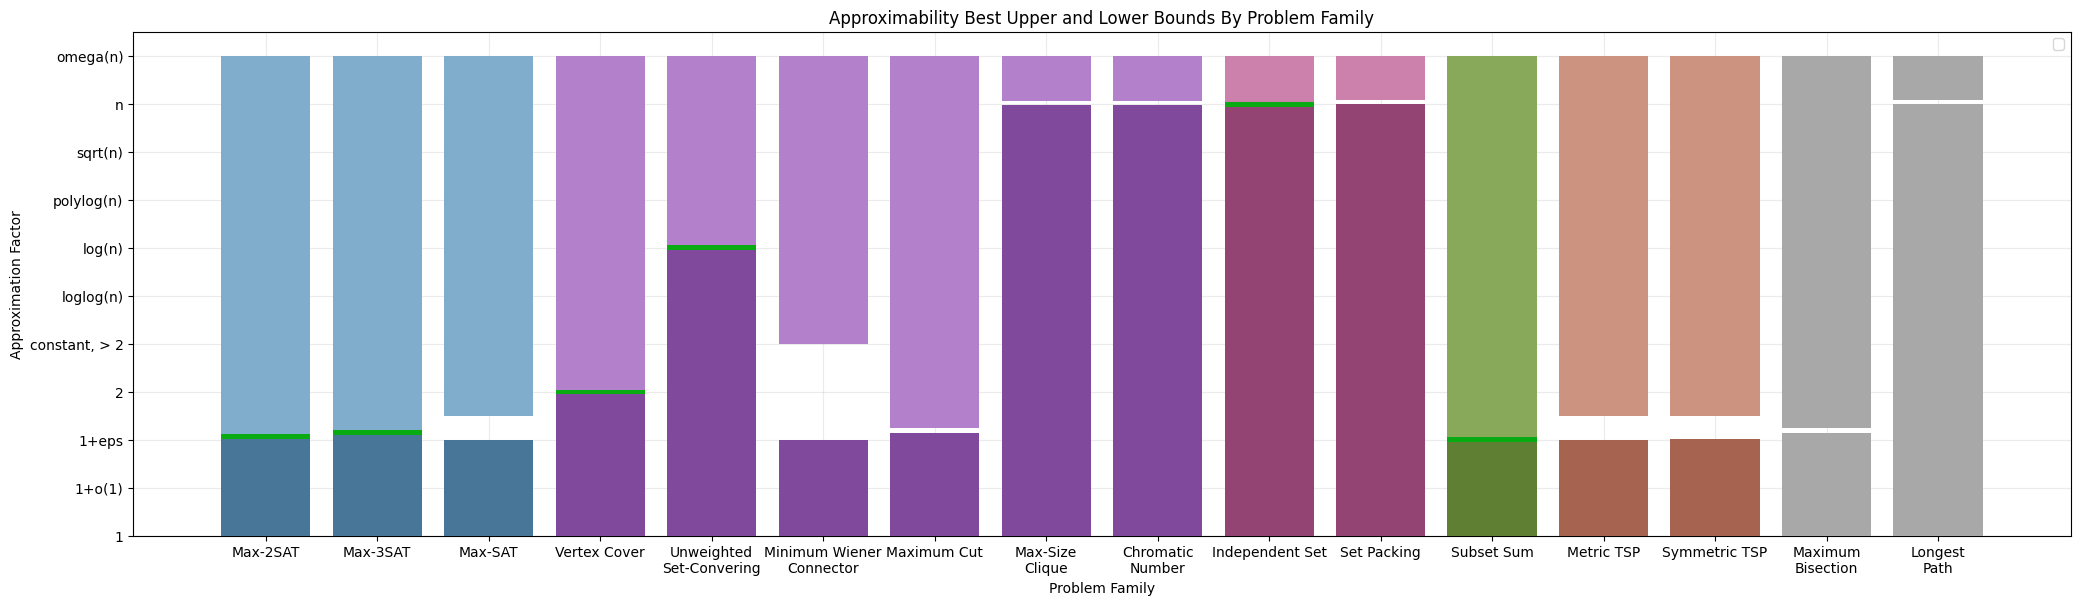

In [272]:


fig, ax = plt.subplots()
fig.set_size_inches(25, 7)
fig.set_facecolor('white')

# Keep this plot independent of stale notebook state from earlier cells.
plot_short_names = {
    **short_names,
    'Longest Path, Directed (Approximate)': 'Longest Path',
    'Longest Path, General (Approximate)': 'Longest Path',
    'Approximate Symmetric TSP (with gamma-parameterized triangle ineq)': 'Symmetric TSP',
}
family_short_names = {
    'Longest Path Problem': 'Longest Path',
}

def plot_family_name(row, family_col, variation_col):
    return plot_short_names.get(row[variation_col], family_short_names.get(row[family_col], None))

plotted_family_names = set(plot_short_names.values()) | set(family_short_names.values())

def filter_data(families, apx, sort_func):
    filtered = sort_func([(f, a) for f, a in zip(families, apx, strict=True) if f in plotted_family_names])
    if not filtered:
        return [], []
    return [list(values) for values in zip(*filtered)]

plot_families_lower = list(approximation_lower_bounds.apply(lambda row: plot_family_name(row, 'Problem Family', 'Problem Variation'), axis=1))
plot_apx_lower = list(approximation_lower_bounds["Approximation Factor Class (Mult)"])
longest_path_lower_mask = pd.Series(plot_families_lower, index=approximation_lower_bounds.index) == 'Longest Path'
print(approximation_lower_bounds.loc[longest_path_lower_mask, ['Problem Family', 'Problem Variation', 'Approximation Factor Class (Mult)']])

plot_families_upper = list(approximation_algorithms.apply(lambda row: plot_family_name(row, 'Family Name', 'Variation'), axis=1))
plot_apx_upper = list(approximation_algorithms["Approximation Factor Class (Mult)"])

top_edge = 10

best_lower = {}
for family, lower_bound in zip(plot_families_lower, plot_apx_lower):
    if family not in best_lower:
        best_lower[family] = lower_bound
    else:
        best_lower[family] = max(best_lower[family], lower_bound)
best_upper = {}
for family, upper_bound in zip(plot_families_upper, plot_apx_upper):
    if family not in best_upper:
        best_upper[family] = upper_bound
    else:
        best_upper[family] = min(best_upper[family], upper_bound)

pp(best_lower)
pp(best_upper)
print('Longest Path lower:', best_lower.get('Longest Path'))
print('Longest Path upper:', best_upper.get('Longest Path'))

tight_families = {}
for family in best_lower:
    if family in best_upper and best_lower[family] == best_upper[family]:
        tight_families[family] = best_lower[family]
    
print(tight_families)


sub_ordering = {
'Max-2SAT': 0,
 'Max-3SAT': 1,
 'Max-SAT': 2,
 'Max-Size\nClique': 14,
 'Chromatic\nNumber': 15,
 'Independent Set': 20,
 'Set Packing': 21,
 'Subset Sum': 22,
 None: 8.98,
 'Maximum Bisection': 40,
 'Longest Path': 41,
 'Maximum Cut': 12,
 'Unweighted\nSet-Convering': 11.5,
 'Metric TSP': 30,
 'Symmetric TSP': 31,
 'Vertex Cover': 11,
 'Minimum Wiener\nConnector': 10}

def sort_families():
    families_low = set(best_lower.keys())
    families_up = set(best_upper.keys())
    families = families_low | families_up
    families = {x: None for x in families if x is not None}
    for family in families:
        if family not in best_upper or family not in best_lower:
            continue
        diff = best_upper[family] - best_lower[family]
        if diff is None:
            continue
        families[family] = diff
    out = list(families.keys())
    print(families)
    def closure(lst): 
        lst.sort(key=lambda x: 1000+sub_ordering[x[0]] if families[x[0]] is None else families[x[0]]+sub_ordering[x[0]])
        return lst
    print(families)
    print(out)
    return closure

sort_func = sort_families()

plot_families_lower, plot_apx_lower = filter_data(list(plot_families_lower), list(plot_apx_lower), sort_func)
plot_families_upper, plot_apx_upper = filter_data(list(plot_families_upper), list(plot_apx_upper), sort_func)

# artifically increase distance for non tight bounds
spacing_amount = 0.1
plot_apx_upper_spaced = [apx if family in tight_families else max(apx, best_lower.get(family, 0)+spacing_amount) 
                  for family, apx in zip(plot_families_upper, plot_apx_upper) ]
upper_lengths = [top_edge - x for x in plot_apx_upper_spaced]

colors = {
'Max-2SAT': '#81adcc',
 'Max-3SAT': '#81adcc',
 'Max-SAT': '#81adcc',
 'Max-Size\nClique': '#b381cc',
 'Chromatic\nNumber': '#b381cc',
 'Independent Set': '#cc81ad',
 'Set Packing': '#cc81ad',
 'Subset Sum': '#88a85a',
 'Maximum Bisection': '#a8a8a8',
 'Longest Path': '#a8a8a8',
 'Maximum Cut': '#b381cc',
 'Unweighted\nSet-Convering': '#b381cc',
 'Metric TSP': '#cc9381',
 'Symmetric TSP': '#cc9381',
 'Vertex Cover': '#b381cc',
 'Minimum Wiener\nConnector': '#b381cc',
 }
colors_lower_dict = {
'Max-2SAT': "#477698",
 'Max-3SAT': '#477698',
 'Max-SAT': '#477698',
 'Max-Size\nClique': "#80499b",
 'Chromatic\nNumber': '#80499b',
 'Independent Set': "#934472",
 'Set Packing': "#934472",
 'Subset Sum': '#5f7f32',
 'Maximum Bisection': '#a8a8a8',
 'Longest Path': '#a8a8a8',
 'Maximum Cut': '#80499b',
 'Unweighted\nSet-Convering': '#80499b',
 'Metric TSP': "#a6634f",
 'Symmetric TSP': '#a6634f',
 'Vertex Cover': '#80499b',
 'Minimum Wiener\nConnector': '#80499b',
 }
print('lower', plot_families_lower)
colors_upper = [colors[x] for x in plot_families_upper]
colors_lower = [colors_lower_dict[x] for x in plot_families_lower]

ax.bar(plot_families_lower, plot_apx_lower, zorder=100, color=colors_lower)
ax.bar(plot_families_upper, upper_lengths, zorder=100, color=colors_upper, bottom=plot_apx_upper_spaced)

# green lines for tight bounds
line_thickness = 0.1
ax.bar(tight_families.keys(), line_thickness, zorder=1000, color='#09ab13', bottom=[x-line_thickness/2 for x in tight_families.values()] )

ax.set_xlabel('Problem Family')
ax.set_ylabel('Approximation Factor')
ax.set_title('Approximability Best Upper and Lower Bounds By Problem Family')
ax.legend(loc="upper right")
tick_label_wraps = {
    'Maximum Bisection': 'Maximum\nBisection',
    'Longest Path': 'Longest\nPath',
}
ax.set_xticks(ax.get_xticks(), [tick_label_wraps.get(label.get_text(), label.get_text()) for label in ax.get_xticklabels()])
fig.subplots_adjust(bottom=0.16)

# stylistic stuff, labels, formatting, etc.
approx_classes = ['1', '1+o(1)', '1+eps', '2', 'constant, > 2', 'loglog(n)', 'log(n)', 'polylog(n)', 'sqrt(n)', 'n', 'omega(n)']
plt.yticks(np.arange(0, 11, 1), approx_classes)
ax.grid(True, alpha=0.25, zorder=0)


fig.show()

# Set Covering (Approx)
# Change Making 
# Graph Edit Distance (Inapprox) (Approx needs looking at)
# Subset Sum (Inapprox) (Approx)
# Turnpike (Special Case Inapprox)
# Finding Frequent Item Sets (Special Case Inapprox)
# Set Packing (Inapprox)


C:\Users\iceco\AppData\Local\Temp\ipykernel_2360\1892109052.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="upper right")
C:\Users\iceco\AppData\Local\Temp\ipykernel_2360\1892109052.py:33: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


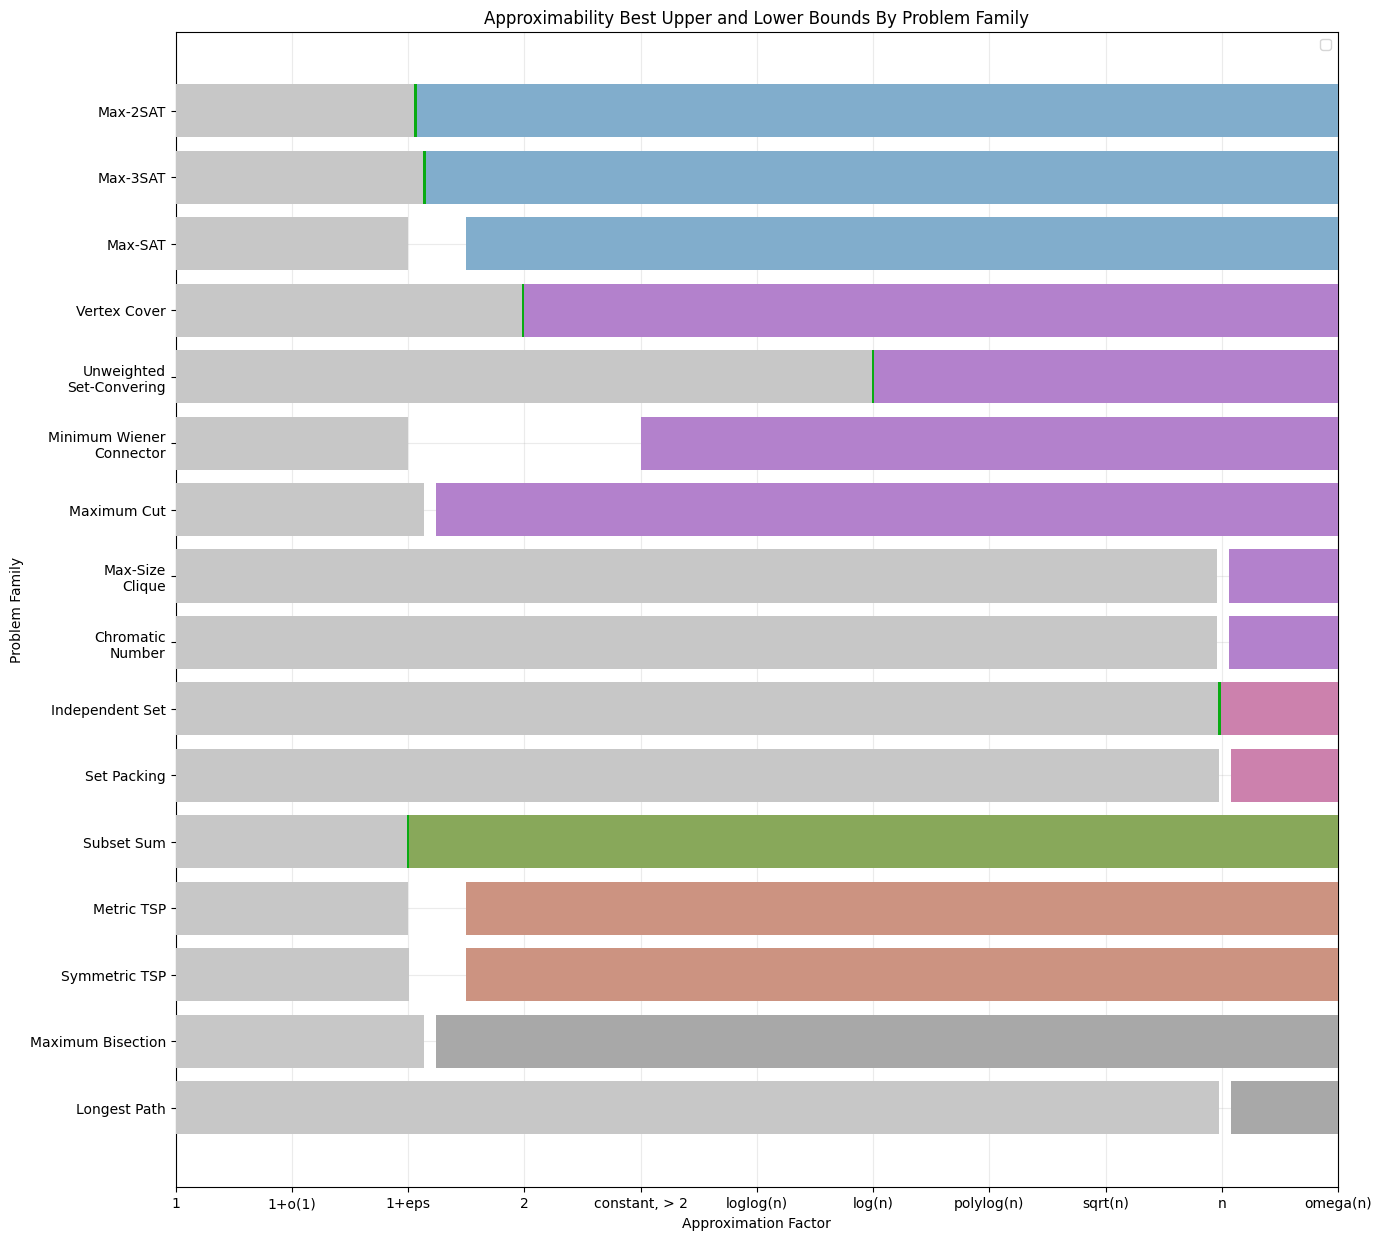

In [273]:

fig, ax = plt.subplots()
fig.set_size_inches(15, 15)
fig.set_facecolor('white')

plot_families_lower_h = list(reversed(plot_families_lower))
plot_families_upper_h = list(reversed(plot_families_upper))
plot_apx_lower_h = list(reversed(plot_apx_lower))
colors_upper_h = list(reversed(colors_upper))
plot_apx_upper_spaced_h = list(reversed(plot_apx_upper_spaced))
upper_lengths_h = list(reversed(upper_lengths))
tf = list(reversed(list(tight_families.keys())))
tfv = list(reversed(list(tight_families.values())))

ax.barh(plot_families_lower_h, plot_apx_lower_h, zorder=100, color='#c7c7c7')
ax.barh(plot_families_upper_h, upper_lengths_h, zorder=100, color=colors_upper_h, left=plot_apx_upper_spaced_h)

# green lines for tight bounds
line_thickness = 0.1
ax.barh(tf, line_thickness/5, zorder=1000, color='#09ab13', left=[x-line_thickness/10 for x in tfv] )

ax.set_ylabel('Problem Family')
ax.set_xlabel('Approximation Factor')
ax.set_title('Approximability Best Upper and Lower Bounds By Problem Family')
ax.set_xmargin(0)
ax.legend(loc="upper right")

# stylistic stuff, labels, formatting, etc.
approx_classes = ['1', '1+o(1)', '1+eps', '2', 'constant, > 2', 'loglog(n)', 'log(n)', 'polylog(n)', 'sqrt(n)', 'n', 'omega(n)']
plt.xticks(np.arange(0, 11, 1), approx_classes)
ax.grid(True, alpha=0.25, zorder=0)


fig.show()


In [274]:
data_labels = ['Tight Nonconstant', 'Tight Constant', 'Constant / PTAS', 'Constant / Constant', '>Constant Factor']

def categorize_gap(lower_class, upper_class):
    if lower_class == upper_class and lower_class <= 4:
        return data_labels[1]
    elif lower_class == upper_class:
        return data_labels[0]
    elif lower_class == 2 and 2 < upper_class < 3:
        return 'Constant / PTAS'
    elif 2 < lower_class < 3 and 2 < upper_class < 3:
        return 'Constant / Constant'
    elif lower_class >= 8.9 and upper_class >= 8.9:
        return '>Constant Factor'
    raise Exception(f'{lower_class}, {upper_class} not recognized')

categories = {}

for k, lower in best_lower.items():
    if k == None or k not in best_upper:
        continue
    upper = best_upper[k]
    category = categorize_gap(lower, upper)
    categories[category] = categories.get(category, 0) + 1
    
data_values = [categories.get(c, 0) for c in data_labels]
colors = ['#bf9bc2', '#80a4d1', '#4f8edb', '#4053bd', '#cc68d9']

print(data_values)

fig, ax = plt.subplots()
ax.set_title('Distribution of Remaining Approximation Factor Gaps')
fig.set_size_inches(10, 10)
fig.set_facecolor('white')
ax.pie(data_values, labels=data_labels, autopct='%1.1f%%', startangle=330, colors=colors)
plt.show()

# TODO: 
# update the labelling
# constant / ptas should be darker than constant / constant
# title should not restrict to "gaps"


Exception: 2.0, 4.0 not recognized

In [ ]:

# make another chart covers all intractable problems with upper bounds,
# not just ones with lower bounds
# upper: ptas / constant / sup 
# lower: none / constant / sup
# 8 cases
# ptas none
# const / const (tight or not)
# sup / sup (tight or not)
# sep by best upper and by tightness in the graph

data_labels = ['Tight Nonconstant', 'Tight Constant', 'Constant / PTAS', 'Constant / Constant', '>Constant Factor']

def categorize_gap(lower_class, upper_class):
    if lower_class == upper_class and lower_class <= 4:
        return data_labels[1]
    elif lower_class == upper_class:
        return data_labels[0]
    elif lower_class == 2 and 2 < upper_class < 3:
        return 'Constant / PTAS'
    elif 2 < lower_class < 3 and 2 < upper_class < 3:
        return 'Constant / Constant'
    elif lower_class >= 8.9 and upper_class >= 8.9:
        return '>Constant Factor'
    raise Exception(f'{lower_class}, {upper_class} not recognized')

categories = {}

for k, lower in best_lower.items():
    if k == None or k not in best_upper:
        continue
    upper = best_upper[k]
    category = categorize_gap(lower, upper)
    categories[category] = categories.get(category, 0) + 1
    
data_values = [categories.get(c, 0) for c in data_labels]
colors = ['#bf9bc2', '#80a4d1', '#4f8edb', '#4053bd', '#cc68d9']

print(data_values)

fig, ax = plt.subplots()
ax.set_title('Distribution of Remaining Approximation Factor Gaps')
fig.set_size_inches(10, 10)
fig.set_facecolor('white')
ax.pie(data_values, labels=data_labels, autopct='%1.1f%%', startangle=330, colors=colors)
plt.show()

# TODO: 
# update the labelling
# constant / ptas should be darker than constant / constant
# title should not restrict to "gaps"


In [ ]:
# unique games vs P neq NP

def fill_best_algo(df, column="Approximation Factor Class (Mult)"):
    best = []
    last_best = 99999
    for index, row in df.iterrows():
        if row[column] < last_best:
            best.append(True)
            last_best = row[column]
        else:
            best.append(False)

    return best
    
def fill_best_lb(df, column="Approximation Factor Class (Mult)"):
    best = []
    last_best = 0
    for index, row in df.iterrows():
        if row[column] > last_best:
            best.append(True)
            last_best = row[column]
        else:
            best.append(False)

    return best


def plot_family_all(family):
    
    df1 = approximation_algorithms.copy()
    df2 = approximation_lower_bounds.copy()

    df1 = df1[df1['Family Name'] == family]
    df2 = df2[df2['Problem Family'] == family]


    # Reduce opcity of point that are not the best
    
    df1['Best'] = fill_best_algo(df1)
    df2['Best'] = fill_best_lb(df2)

    plt.figure(figsize=(6, 6))
    # hide in legend
    plt.scatter(df1['Year'], df1['Approximation Factor Class (Mult)']+1, color='#DD444422')
    plt.scatter(df2['Year'], df2['Approximation Factor Class (Mult)']+1, color='#5975A422')

    if len(df1) > 0:
        best_approximate = df1[df1['Best']]
        last_row = best_approximate.iloc[-1:].copy()
        last_row['Year'] = 2024
        best_approximate = pd.concat([best_approximate, last_row], ignore_index=True)
        plt.scatter(best_approximate['Year'], best_approximate['Approximation Factor Class (Mult)']+1, label='approx algo', color='#DD4444')
        plt.step(best_approximate['Year'], best_approximate['Approximation Factor Class (Mult)']+1, where='post', color='#DD4444')

    if len(df2) > 0:
        best_lb = df2[df2['Best']]
        last_row2 = best_lb.iloc[-1:].copy()
        last_row2['Year'] = 2024
        best_lb = pd.concat([best_lb, last_row2], ignore_index=True)
        plt.scatter(best_lb['Year'], best_lb['Approximation Factor Class (Mult)']+1, label='lower bound', color='#5975A4')
        plt.step(best_lb['Year'], best_lb['Approximation Factor Class (Mult)']+1, where='post', color='#5975A4')
        
    current_best_lb = best_lb['Approximation Factor Class (Mult)'].iloc[-1]
    current_best_approx = best_approximate['Approximation Factor Class (Mult)'].iloc[-1]
    if current_best_lb == current_best_approx:
        matching_year = min(best_lb['Year'].iloc[-2], best_approximate['Year'].iloc[-1])
        plt.scatter([2024], [current_best_lb+1], color='green')
        plt.step([matching_year, 2024], [current_best_lb+1]*2, where='post', color='green')
        #plt.figtext(0.8, (current_best_lb+1.3)/12, str(best_lb['Exact Inapprox. Ratio'].iloc[-1]), ha='center', fontsize=10)
        


    plt.yticks(np.arange(1, 12, 1), ['1', '1+o(1)', '1+eps', '2', 'constant, > 2', 'loglog(n)', 'log(n)', 'polylog(n)', 'sqrt(n)', 'n', 'omega(n)'])


    plt.xlabel('Year')
    plt.ylabel('Approx Class')
    plt.legend()
    plt.title(family)
    
    plt.savefig('figures/prog-all/'+family+'.png', bbox_inches='tight')
    
    plt.show()



ValueError: Multi-dimensional indexing (e.g. `obj[:, None]`) is no longer supported. Convert to a numpy array before indexing instead.

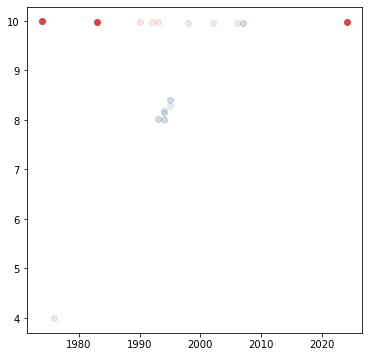

In [ ]:
for family in approximation_algorithms['Family Name'].unique():
    plot_family_all(family)

In [ ]:
def plot_family_cst(family):
    
    df1 = approximation_algorithms.copy()
    df2 = approximation_lower_bounds.copy()

    df1 = df1[df1['Family Name'] == family]
    df1 = df1[df1['Approximation Factor Class (Mult)'] <= 4.5]
    df2 = df2[df2['Problem Family'] == family]
    df2 = df2[df2['Approximation Factor Class (Mult)'] <= 4.5]
    
    if df1.size > 0:
    
        df1['Best'] = fill_best_algo(df1)
        df2['Best'] = fill_best_lb(df2)

        plt.figure(figsize=(6, 6))
        plt.scatter(df1['Year'], df1['Approximation Factor Class (Mult)']+1, color='#DD444422')
        plt.scatter(df2['Year'], df2['Approximation Factor Class (Mult)']+1, color='#5975A422')

        if len(df1) > 0:
            best_approximate = df1[df1['Best']]
            last_row = best_approximate.iloc[-1:].copy()
            last_row['Year'] = 2024
            best_approximate = pd.concat([best_approximate, last_row], ignore_index=True)
            plt.scatter(best_approximate['Year'], best_approximate['Approximation Factor Class (Mult)']+1, label='approx algo', color='#DD4444')
            plt.step(best_approximate['Year'], best_approximate['Approximation Factor Class (Mult)']+1, where='post', color='#DD4444')

        if len(df2) > 0:
            best_lb = df2[df2['Best']]
            last_row2 = best_lb.iloc[-1:].copy()
            last_row2['Year'] = 2024
            best_lb = pd.concat([best_lb, last_row2], ignore_index=True)
            plt.scatter(best_lb['Year'], best_lb['Approximation Factor Class (Mult)']+1, label='lower bound', color='#5975A4')
            plt.step(best_lb['Year'], best_lb['Approximation Factor Class (Mult)']+1, where='post', color='#5975A4')
        

        current_best_lb = best_lb['Approximation Factor Class (Mult)'].iloc[-1]
        current_best_approx = best_approximate['Approximation Factor Class (Mult)'].iloc[-1]
        if current_best_lb == current_best_approx:
            matching_year = min(best_lb['Year'].iloc[-2], best_approximate['Year'].iloc[-1])
            plt.scatter([2024], [current_best_lb+1], color='green')
            plt.step([matching_year, 2024], [current_best_lb+1]*2, where='post', color='green')

        plt.yticks(np.arange(1, 6, 1), ['1', '1+o(1)', '1+eps', '2', 'constant, > 2'])


        plt.xlabel('Year')
        plt.ylabel('Approx Class')
        plt.legend()
        plt.title(family + " (cst factor)")
        
        plt.savefig('figures/prog-cst/'+family+'.png', bbox_inches='tight')
        
        plt.show()


In [ ]:
for family in approximation_algorithms['Family Name'].unique():
    plot_family_cst(family)

In [ ]:
#approximation_algorithms['Approximation Factor Class (Mult)'].tolist()

In [ ]:
def plot_family_runtime_vs_approx(family):
    
    df1 = approximation_algorithms.copy()
    df2 = approximation_lower_bounds.copy()

    df1 = df1[df1['Family Name'] == family]
    df2 = df2[df2['Problem Family'] == family]

    
    df1.sort_values(by=['Approximation Factor Class (Mult)', 'Time Complexity Class'], ascending=[True, False], inplace=True)
    df2.sort_values(by=['Approximation Factor Class (Mult)'], inplace=True)
    
    trivial_algo = 9
    if family == 'The Traveling-Salesman Problem':
        trivial_algo = 10
    
    algos_x = df1['Approximation Factor Class (Mult)'].tolist()+[trivial_algo]
    algos_y = df1['Time Complexity Class'].tolist()+[3]
    
    inapprox_x = df2['Approximation Factor Class (Mult)'].tolist()
    inapprox_y = [7]*df2.shape[0]
    
    for i in range(len(algos_x)):
        algos_x[i] += 1
    
    for i in range(len(inapprox_x)):
        inapprox_x[i] += 1

    # Reduce opcity of point that are not the best
    
    best_algos_x = []
    best_algos_y = []
    best_algo_runtime = 999
    for i in range(len(algos_x)):
        if algos_y[i] < best_algo_runtime:
            if len(best_algos_x) > 0 and algos_x[i] == best_algos_x[-1]:
                best_algos_y[-1] = algos_y[i]
            else:
                best_algos_x.append(algos_x[i])
                best_algos_y.append(algos_y[i])
            best_algo_runtime = algos_y[i]
    
    best_inapprox_x = []
    best_inapprox_y = []
    best_inapprox_runtime = 999
    for i in range(len(inapprox_x)-1, -1, -1):
        if inapprox_y[i] < best_inapprox_runtime:
            if len(best_inapprox_x) > 0 and inapprox_x[i] == best_inapprox_x[-1]:
                best_inapprox_x[-1] = inapprox_x[i]
            else:
                best_inapprox_x.insert(0, inapprox_x[i])
                best_inapprox_y.insert(0, inapprox_y[i])
            best_inapprox_runtime = inapprox_y[i]
    
    #df1['Best'] = fill_best_algo(df1)
    #df2['Best'] = fill_best_lb(df2)

    plt.figure(figsize=(9, 6))
    # hide in legend
    plt.scatter(algos_x, algos_y, color='#DD444412')
    plt.scatter(inapprox_x, inapprox_y, color='#5975A412')
    
    plt.scatter(best_algos_x, best_algos_y, label='approx algo', color='#DD4444')
    plt.scatter(best_inapprox_x, best_inapprox_y, label='inapprox', color='#5975A4')
    plt.scatter([1], [9], color='#9B5D74')
    
    best_algos_x = [1]+best_algos_x+[11.5]
    best_algos_y = [9]+best_algos_y+best_algos_y[-1:]
    
    best_inapprox_x = [1]+best_inapprox_x+[11.5]
    best_inapprox_y = [9]+best_inapprox_y+[1]#best_inapprox_y[0:1]+best_inapprox_y+[1]
    
    plt.step(best_algos_x, best_algos_y, where='post', color='#DD4444')
    plt.step(best_inapprox_x, best_inapprox_y, where='pre', color='#5975A4')
    
    plt.fill_between(best_algos_x, best_algos_y, 9.5, step='post', facecolor='#DD444450')
    plt.fill_between(best_inapprox_x, 1, best_inapprox_y, step='pre', facecolor='#5975A450')
        


    plt.xticks(np.arange(1, 12, 1), ['$1$', '$1+o(1)$', '$1+\epsilon$', '$2$', '$C_{>2}$', '$\log\log(n)$', '$\log(n)$', '$poly\log(n)$', '$\sqrt{n}$', '$n$', '$\omega(n)$'])
    plt.yticks(np.arange(1, 10, 1), ['Constant', 'Polylogarithmic', 'Linear', 'Quasilinear', 'Quadratic', 'Cubic', 'Polynomial ($n^{O(1)}$)', 'Quasipolynomial', 'Exponential'])


    plt.xlabel('Approx Class')
    plt.ylabel('Time Complexity')
    plt.legend()
    plt.title(family)
    
    plt.savefig('figures/time-vs-approx/'+family+'.png', bbox_inches='tight')
    
    plt.show()



In [ ]:
for family in approximation_algorithms['Family Name'].unique():
    plot_family_runtime_vs_approx(family)